# Mudança de conceito no B-8802B — o que foi feito e quando o detector disparou

**Equipamento:** B-8802B (bomba) · **Dados:** mai–jul/2022 e jan/2025 a ago/2026 · **Validação extra:** B-4064A ·
**Código:** `src/transpetro_modelos/drift/` (`detectors.py`, `residuo.py`, `monitor.py`, `ciclo.py`)

## Resumo
1. **Mudança de conceito** é quando o normal do equipamento muda (manutenção, regime de operação) e o modelo de
   anomalia, treinado no normal antigo, passa a alarmar sem falha nenhuma. Falha é o que o modelo deve alertar;
   mudança de conceito é o que obriga a atualizar o modelo.
2. **Os dados primeiro:** em alguns períodos 5 dos 8 sensores ficam **congelados** juntos (falha de aquisição). O
   modelo de anomalia não percebe, e o detector confundia com mudança. Esses trechos agora saem do treino e do
   detector, e viram um aviso próprio no monitor (M7).
3. **O caso real de 2025:** depois do reparo de 2022 o modelo antigo ficou em alarme 12 % do tempo. O detector KS
   disparou em **06/01/2025, 4 dias** depois do início dos dados novos. Depois do disparo, a distribuição nova vira a
   referência e amadurece até 12 meses.
4. **2026: uma mudança que o KS não viu.** Em **28/03/2026**, logo depois de uma parada da bomba, o mancal LA passou a
   operar ~6 °C mais frio. O KS na série bruta não dispara de forma robusta: a estação deixa o limite perto do máximo.
   Um detector no **resíduo** de um modelo de comportamento normal (estação descontada) dispara em **4 dias**, sem
   nenhum disparo falso em 2025.
5. **Validação no B-4064A:** o detector no resíduo achou a mudança de conceito conhecida em 2 dias e não disparou à
   toa nem com referência curta (o KS dá 2 disparos falsos ali, pela estação). Uma janela de referência deslizante
   foi testada e descartada: ela absorve a mudança em um mês.

Tudo roda local, sem treinar nada.

In [1]:
import sys, json, warnings
from pathlib import Path
import numpy as np, pandas as pd
import matplotlib.pyplot as plt, matplotlib.dates as mdates
%config InlineBackend.figure_format = "retina"
warnings.filterwarnings("ignore")
PROJECT_ROOT = Path.cwd().resolve()
while not (PROJECT_ROOT / "src").exists(): PROJECT_ROOT = PROJECT_ROOT.parent
sys.path.insert(0, str(PROJECT_ROOT / "src"))
DEP = PROJECT_ROOT / "deploy_v2/Transpetro"; sys.path.insert(0, str(DEP))
import simpred_inference as si
from transpetro_modelos.drift import monitor as mon
from transpetro_modelos.drift.detectors import CalibratedKSDetector
from transpetro_modelos.drift.ciclo import simular_ciclo
from transpetro_modelos.drift.residuo import ResidualLevelDetector

B_ANTIGO = DEP / "B-8802B/modelos/model_2022-05-15_2022-07-21_VAE"         # modelo de 2022
B_ATUAL = DEP / "B-8802B-2025/modelos/model_2025-01-01_2026-08-10_VAE"     # modelo em produção (treino: 2025)
DADOS = DEP / "B-8802B-2025/dados/2025_2026/data_2025-01-01_2026-08-10_raw.csv"
raw = si.carregar_dados(DADOS)
raw22 = si.carregar_dados(next((DEP / "B-8802B/dados").rglob("*_raw.csv")))

ref_antiga = json.loads((B_ANTIGO / "drift_ref.json").read_text())
COLS = list(ref_antiga["sensors"])
serie_bruta = mon._temporal_steps(B_ANTIGO, raw)[COLS]     # 2025–26: só bomba operando, passos do pipeline
congelado = si.frozen_mask(serie_bruta)                     # 3+ sensores com o mesmo valor por 12 h+
serie = serie_bruta[~congelado.to_numpy()]                  # o que o detector usa
serie22 = mon._temporal_steps(B_ANTIGO, raw22)[COLS]
ref22 = serie22.loc[ref_antiga["reference_window"][0]:ref_antiga["reference_window"][1]]
UNID = {"Pressão Sucção": "bar", "Pressão Descarga": "bar", "Vibração Bomba LA": "mm/s",
        "Vibração Bomba LNA": "mm/s", "Temperatura Bomba LA": "°C"}
CORES = dict(zip(COLS, ["tab:blue", "tab:orange", "tab:red", "tab:purple", "tab:brown"]))

def trechos(mask):
    """[(início, fim)] dos blocos contínuos True."""
    m = mask[mask]
    if m.empty: return []
    g = (m.index.to_series().diff() > pd.Timedelta(hours=24)).cumsum()       # blocos a menos de 1 dia = mesmo episódio
    return [(b.index.min(), b.index.max()) for _, b in m.groupby(g)]
CONGELADOS = trechos(congelado)
print(f"2022: {len(serie22)} amostras de 5 min | 2025–26: {len(serie_bruta)}, das quais {congelado.sum()} "
      f"({congelado.sum() * 5 / 60:.0f} h) com dado congelado | sensores do modelo: {COLS}")

2022: 10792 amostras de 5 min | 2025–26: 145180, das quais 4238 (353 h) com dado congelado | sensores do modelo: ['Pressão Sucção', 'Pressão Descarga', 'Vibração Bomba LA', 'Vibração Bomba LNA', 'Temperatura Bomba LA']


## 1. Antes de tudo: o dado congelado

Em alguns períodos vários sensores ficam com **exatamente o mesmo valor** por dias. Não é o equipamento: é falha de
aquisição (o histórico do IFIX repete o último valor recebido quando o dado para de chegar).

**A regra** (`remove_frozen_segments`, em `src/transpetro_modelos/data/preprocessing.py` e no `simpred_inference.py`
do pacote de deploy): **3 ou mais sensores com o mesmo valor ao mesmo tempo, por 12 h ou mais**. Um sensor sozinho
parado por horas é normal aqui: o histórico só grava quando o valor muda, e a pressão de descarga fica até 16 h
constante em operação normal. Por isso a regra exige vários sensores juntos.

,início,fim,duração (h),sensores congelados (dos 8)
0,02/01/2025 06:45,03/01/2025 05:00,22,"Pressão Sucção, Temperatura Bomba LNA, Tempera..."
1,15/05/2025 02:55,23/05/2025 09:20,198,"Pressão Sucção, Temperatura Bomba LNA, Tempera..."
2,22/02/2026 20:55,28/02/2026 18:10,141,"Pressão Sucção, Temperatura Bomba LNA, Tempera..."
3,03/03/2026 00:25,04/03/2026 09:30,33,"Pressão Sucção, Temperatura Bomba LNA, Tempera..."


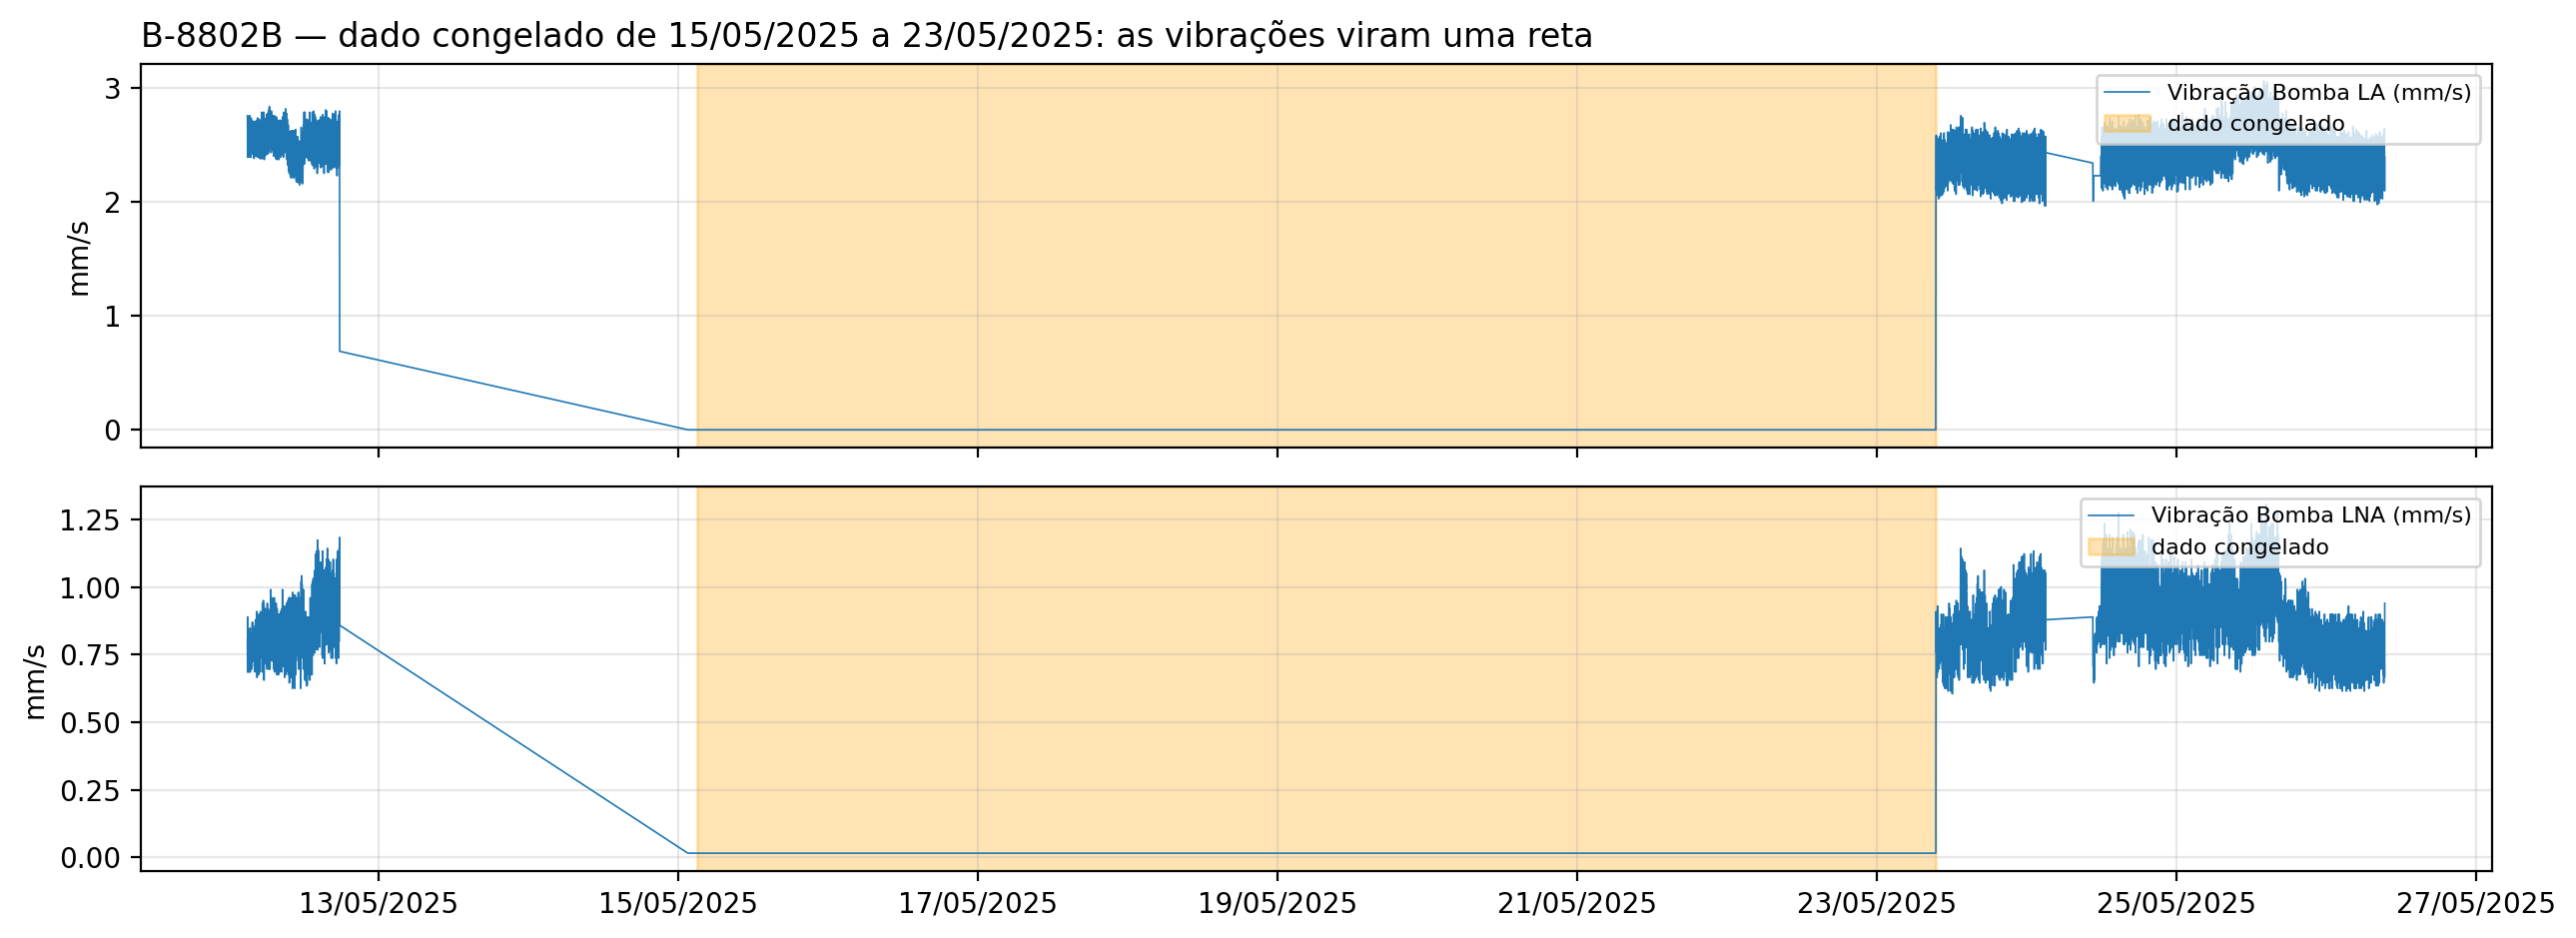

modelo atual durante o dado congelado: 0 alarmes em 4098 pontos; erro mediano 0.057 (no resto: 0.062)


In [2]:
op = raw[raw["Pressão Descarga"] > 35]
g = op.groupby(pd.to_datetime(op.index.date)); dp = g.std(); n = g.size()
dia_parado = (dp == 0) & (n.to_numpy()[:, None] >= 200)
linhas = []
for a, b in CONGELADOS:
    dias = dia_parado.loc[a.normalize():b.normalize()]
    linhas.append({"início": f"{a:%d/%m/%Y %H:%M}", "fim": f"{b:%d/%m/%Y %H:%M}",
                   "duração (h)": round((b - a).total_seconds() / 3600),
                   "sensores congelados (dos 8)": ", ".join(c for c in dias.columns if dias[c].any())})
display(pd.DataFrame(linhas))

a, b = max(CONGELADOS, key=lambda e: e[1] - e[0])      # o episódio mais longo
ini, fim = a - pd.Timedelta(days=3), b + pd.Timedelta(days=3)
fig, axes = plt.subplots(2, 1, figsize=(13, 4.8), sharex=True)
for ax, c in zip(axes, ["Vibração Bomba LA", "Vibração Bomba LNA"]):
    x = op.loc[ini:fim, c]
    ax.plot(x.index, x, linewidth=0.6, label=f"{c} ({UNID[c]})")
    ax.axvspan(a, b, color="orange", alpha=0.3, label="dado congelado")
    ax.set_ylabel(UNID[c]); ax.grid(alpha=0.3); ax.legend(loc="upper right", fontsize=8)
axes[0].set_title(f"B-8802B — dado congelado de {a:%d/%m/%Y} a {b:%d/%m/%Y}: as vibrações viram uma reta", loc="left")
axes[-1].xaxis.set_major_formatter(mdates.DateFormatter("%d/%m/%Y")); plt.tight_layout(); plt.show()

inf = si.prever(B_ATUAL, si.carregar_modelo(B_ATUAL), si.preprocessar(B_ATUAL, raw))
fa = si.frozen_mask(mon._temporal_steps(B_ATUAL, raw)).reindex(inf.index, fill_value=False)
print(f"modelo atual durante o dado congelado: {inf['is_anomaly'][fa].sum()} alarmes em {fa.sum()} pontos; "
      f"erro mediano {inf['reconstruction_error'][fa].median():.3f} (no resto: {inf['reconstruction_error'][~fa].median():.3f})")

**Por que isso importa.** Os valores congelados são plausíveis, então o **modelo de anomalia não percebe**:
erro igual ao normal e nenhum alarme. Se uma falha começasse num desses trechos, ninguém veria. Por isso:
- o monitor ganhou o indicador **M7 — dado congelado**: qualquer hora congelada na semana deixa o semáforo amarelo,
  para a instrumentação verificar;
- esses trechos ficam **fora do detector de mudança de conceito**, na calibração e na varredura (antes ele
  disparava neles, como se fosse mudança);
- o passo `remove_frozen_segments` está disponível no pipeline para os próximos treinos.

Daqui em diante tudo usa a série sem o dado congelado.

## 2. Como o detector funciona

Para cada sensor, o detector compara a distribuição de **um dia** de operação com a distribuição de um
**período de referência** (o normal aprendido). A comparação é o teste de Kolmogorov–Smirnov: o valor **D** é a
maior distância vertical entre as duas curvas acumuladas abaixo. D vai de 0 (iguais) a 1 (sem sobreposição).

- **Limite de cada sensor:** o maior D entre cada dia da referência e a referência inteira, ou seja, "o dia mais
  diferente que o normal já teve". A referência é resumida por 2.000 quantis (não por um sorteio), então o limite
  não depende de semente nem do tamanho da amostra.
- **Dia diferente:** algum sensor passou do seu limite. "Dia" aqui é uma janela de 288 leituras de 5 min com a
  bomba operando (24 h de operação), não o dia do calendário.
- **Disparo:** 3 dos últimos 5 dias diferentes. O detector informa por quais sensores e depois zera a contagem.
  Uma parada de mais de 3 dias também zera a contagem.

A figura usa a referência do modelo antigo (mai–jun/2022) e a vibração do mancal LA: à esquerda um dia normal de
2022, à direita uma janela de 2025 que contou para o disparo.

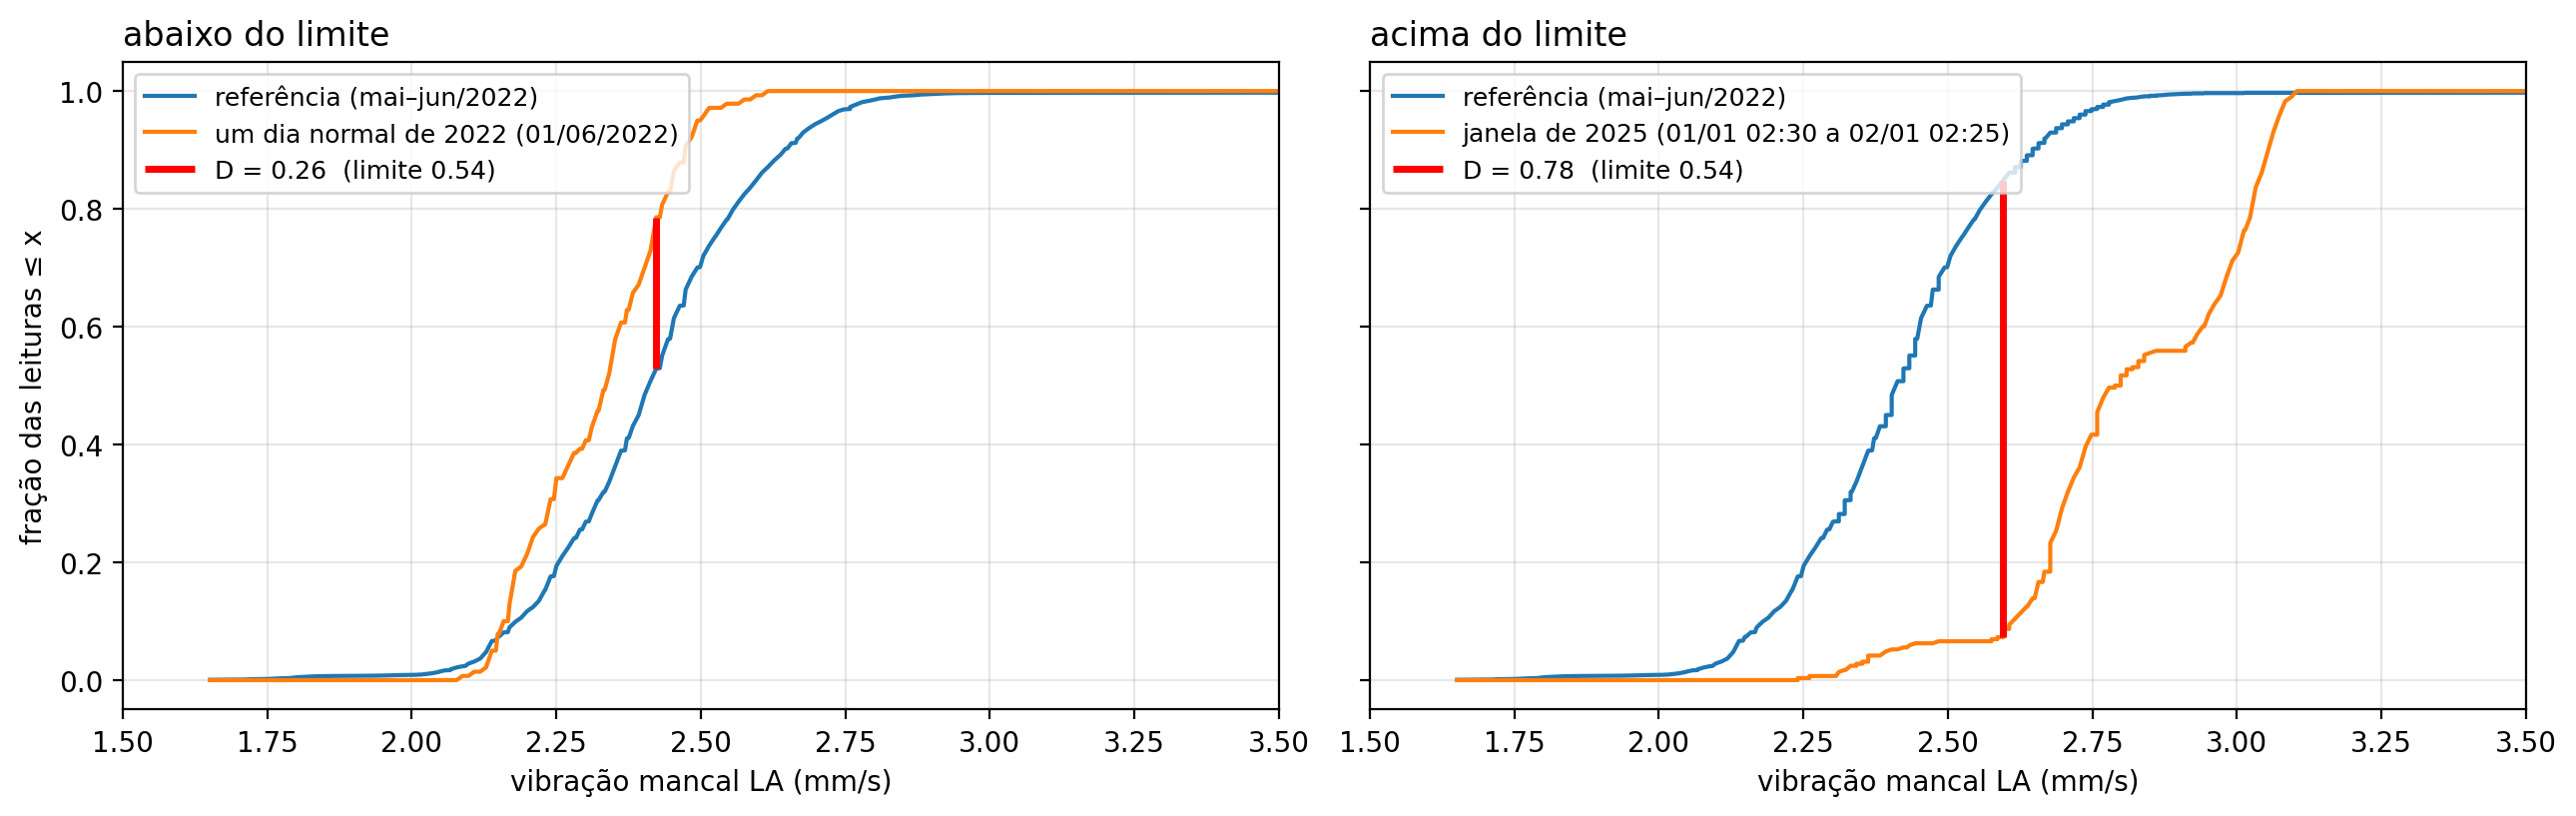

In [3]:
det_antigo = CalibratedKSDetector(ref22, window_size=288, n_reference=mon.M6_NREF, sampling="quantile")   # referência de 2022
d_antigo, disp_antigo = det_antigo.scan(serie, reset_gap=mon.M6_RESET_GAP)
razao = d_antigo / np.asarray(det_antigo.d_crit)              # D ÷ limite, por janela e sensor
j = COLS.index("Vibração Bomba LA"); amostra = np.sort(det_antigo.samples[j]); limite = det_antigo.d_crit[j]
t_jan = razao.loc[:disp_antigo[0][0], "Vibração Bomba LA"].idxmax()     # janela de VLA mais diferente até o disparo
janela = serie.loc[:t_jan, "Vibração Bomba LA"].iloc[-288:]
dias = [("um dia normal de 2022 (01/06/2022)", ref22.loc["2022-06-01", "Vibração Bomba LA"]),
        (f"janela de 2025 ({janela.index.min():%d/%m %H:%M} a {janela.index.max():%d/%m %H:%M})", janela)]
fig, axes = plt.subplots(1, 2, figsize=(13, 4.2), sharey=True)
for ax, (nome, x) in zip(axes, dias):
    x = np.sort(x.values); grade = np.unique(np.concatenate([amostra, x]))
    F_ref = np.searchsorted(amostra, grade, side="right") / len(amostra)
    F_dia = np.searchsorted(x, grade, side="right") / len(x)
    k = np.argmax(np.abs(F_ref - F_dia)); D = abs(F_ref[k] - F_dia[k])
    ax.plot(grade, F_ref, label="referência (mai–jun/2022)"); ax.plot(grade, F_dia, label=nome)
    ax.vlines(grade[k], min(F_ref[k], F_dia[k]), max(F_ref[k], F_dia[k]), color="red", linewidth=2.5,
              label=f"D = {D:.2f}  (limite {limite:.2f})")
    ax.set_xlim(1.5, 3.5); ax.set_xlabel("vibração mancal LA (mm/s)"); ax.grid(alpha=0.3); ax.legend(loc="upper left", fontsize=9)
    ax.set_title(("acima" if D > limite else "abaixo") + " do limite", loc="left")
axes[0].set_ylabel("fração das leituras ≤ x"); plt.tight_layout(); plt.show()

## 3. O caso real: o normal mudou depois do reparo de 2022

O modelo de 2022 foi calibrado em mai–jun/2022. Lendo os dados de 2025, cada janela é comparada com essa
referência. Em cima, a vibração do mancal LA (média horária) com a faixa normal de 2022. Embaixo, **uma barra por
janela de 24 h de operação**: a altura é o D ÷ limite do sensor que mais se afastou do normal, e a **cor diz qual
sensor** foi. Barra cinza = nenhum sensor passou do limite. O disparo sai quando 3 das últimas 5 barras são
coloridas.

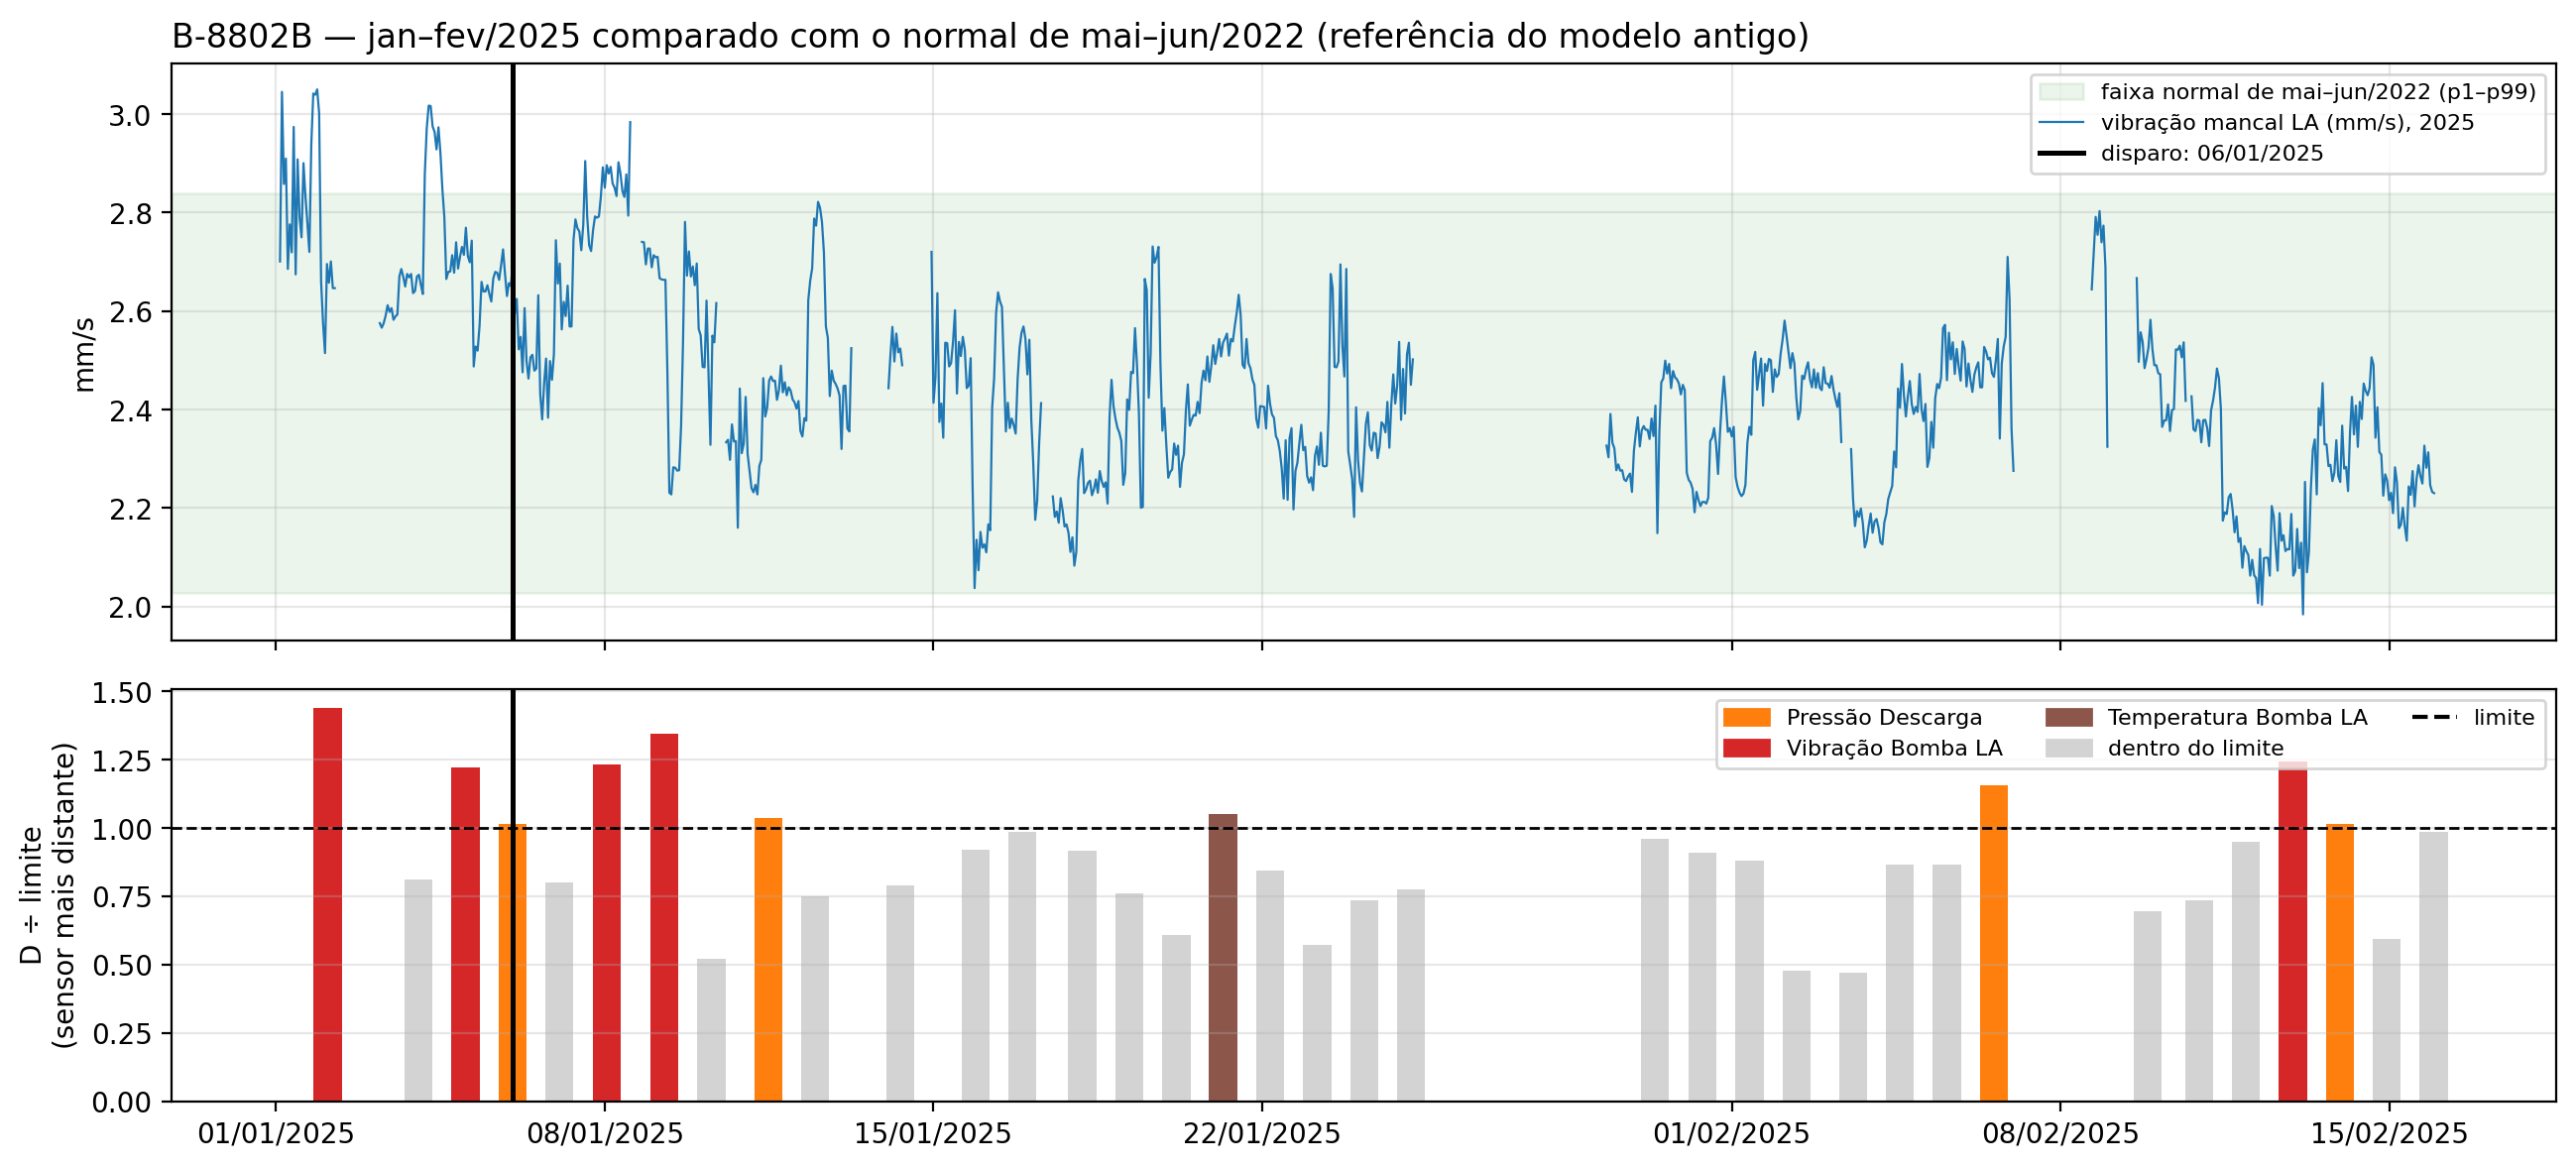

1º disparo: 06/01/2025 00:45, 4 dias depois do início dos dados de 2025, via Pressão Descarga, Vibração Bomba LA
o modelo de 2022 nesse período: alarme em 12.2 % do tempo, sem falha nenhuma
semáforo semanal do monitor: 1º vermelho na semana de 26/01/2025


In [4]:
t_disp, s_disp = disp_antigo[0]
ini, fim = "2025-01-01", "2025-02-15"
h = serie.loc[ini:fim, "Vibração Bomba LA"].resample("1h").mean().asfreq("1h")
lo, hi = ref22["Vibração Bomba LA"].quantile([0.01, 0.99])
r = razao.loc[ini:fim]; pior_v, pior_s = r.max(axis=1), r.idxmax(axis=1)
fig, axes = plt.subplots(2, 1, figsize=(13, 6), sharex=True, gridspec_kw={"height_ratios": [1.4, 1]})
axes[0].axhspan(lo, hi, color="green", alpha=0.08, label="faixa normal de mai–jun/2022 (p1–p99)")
axes[0].plot(h.index, h, linewidth=0.8, label="vibração mancal LA (mm/s), 2025")
axes[0].axvline(t_disp, color="black", linewidth=1.8, label=f"disparo: {t_disp:%d/%m/%Y}")
axes[0].set_ylabel("mm/s"); axes[0].grid(alpha=0.3); axes[0].legend(loc="upper right", fontsize=8)
axes[0].set_title("B-8802B — jan–fev/2025 comparado com o normal de mai–jun/2022 (referência do modelo antigo)", loc="left")
cores = [CORES[s] if v > 1 else "lightgray" for v, s in zip(pior_v, pior_s)]
axes[1].bar(pior_v.index, pior_v, width=0.6, color=cores)
axes[1].axhline(1, color="black", linestyle="--", linewidth=1)
axes[1].axvline(t_disp, color="black", linewidth=1.8)
from matplotlib.patches import Patch
from matplotlib.lines import Line2D
leg = [Patch(color=CORES[c], label=c) for c in COLS if ((pior_s == c) & (pior_v > 1)).any()]
leg += [Patch(color="lightgray", label="dentro do limite"), Line2D([], [], color="black", linestyle="--", label="limite")]
axes[1].set_ylabel("D ÷ limite\n(sensor mais distante)"); axes[1].grid(alpha=0.3, axis="y")
axes[1].legend(handles=leg, loc="upper right", fontsize=8, ncol=3)
axes[1].xaxis.set_major_formatter(mdates.DateFormatter("%d/%m/%Y")); plt.tight_layout(); plt.show()

print(f"1º disparo: {t_disp:%d/%m/%Y %H:%M}, {(t_disp - serie.index.min()).days} dias depois do início dos dados de 2025, via {', '.join(s_disp)}")
inf22 = pd.read_csv(PROJECT_ROOT / "results/monitor_drift/b8802b_modelo2022_em_2025-26_inferencia.csv", index_col=0, parse_dates=True)
print(f"o modelo de 2022 nesse período: alarme em {100 * inf22['is_anomaly'].mean():.1f} % do tempo, sem falha nenhuma")
sem = mon.weekly_table(inf22, json.loads((B_ANTIGO / "alarm.json").read_text())["threshold_calibration"]["mean_normal"])
tl = mon.evaluate(sem)["timeline"]
print(f"semáforo semanal do monitor: 1º vermelho na semana de {tl[tl == 'vermelho'].index.min():%d/%m/%Y}")

Sem o detector, essa mudança só foi percebida ~20 meses depois, quando os alarmes do modelo de 2022 já não
faziam sentido. Com ele, o aviso sai em menos de uma semana, e o semáforo semanal confirma em vermelho na 4ª semana.

Repare que a vibração de 2025 fica quase toda **dentro** da faixa de 2022 e mesmo assim o detector dispara: ele não
olha se o valor saiu da faixa, olha se a **forma da distribuição** mudou (em 2025 ela passa mais tempo na parte de
cima da faixa).

## 4. O que acontece depois do disparo: a referência nova vira a cerca

Depois de um disparo confirmado pela operação como normal novo (`src/transpetro_modelos/drift/ciclo.py`):
1. **Quarentena de 30 dias:** o detector não dispara; o sistema só coleta o comportamento novo.
2. **Recalibração:** a referência passa a ser os dados desde o disparo.
3. **Maturação:** a cada 30 dias a referência é refeita com tudo o que acumulou, até 12 meses. Um disparo nessa
   fase não é mudança nova: só antecipa a recalibração, porque a referência ainda não cobre o ano todo.
4. **Madura:** com ~12 meses a referência fica fixa até o próximo disparo.

Simulamos o ciclo inteiro sobre 2025–26, partindo da referência de 2022.

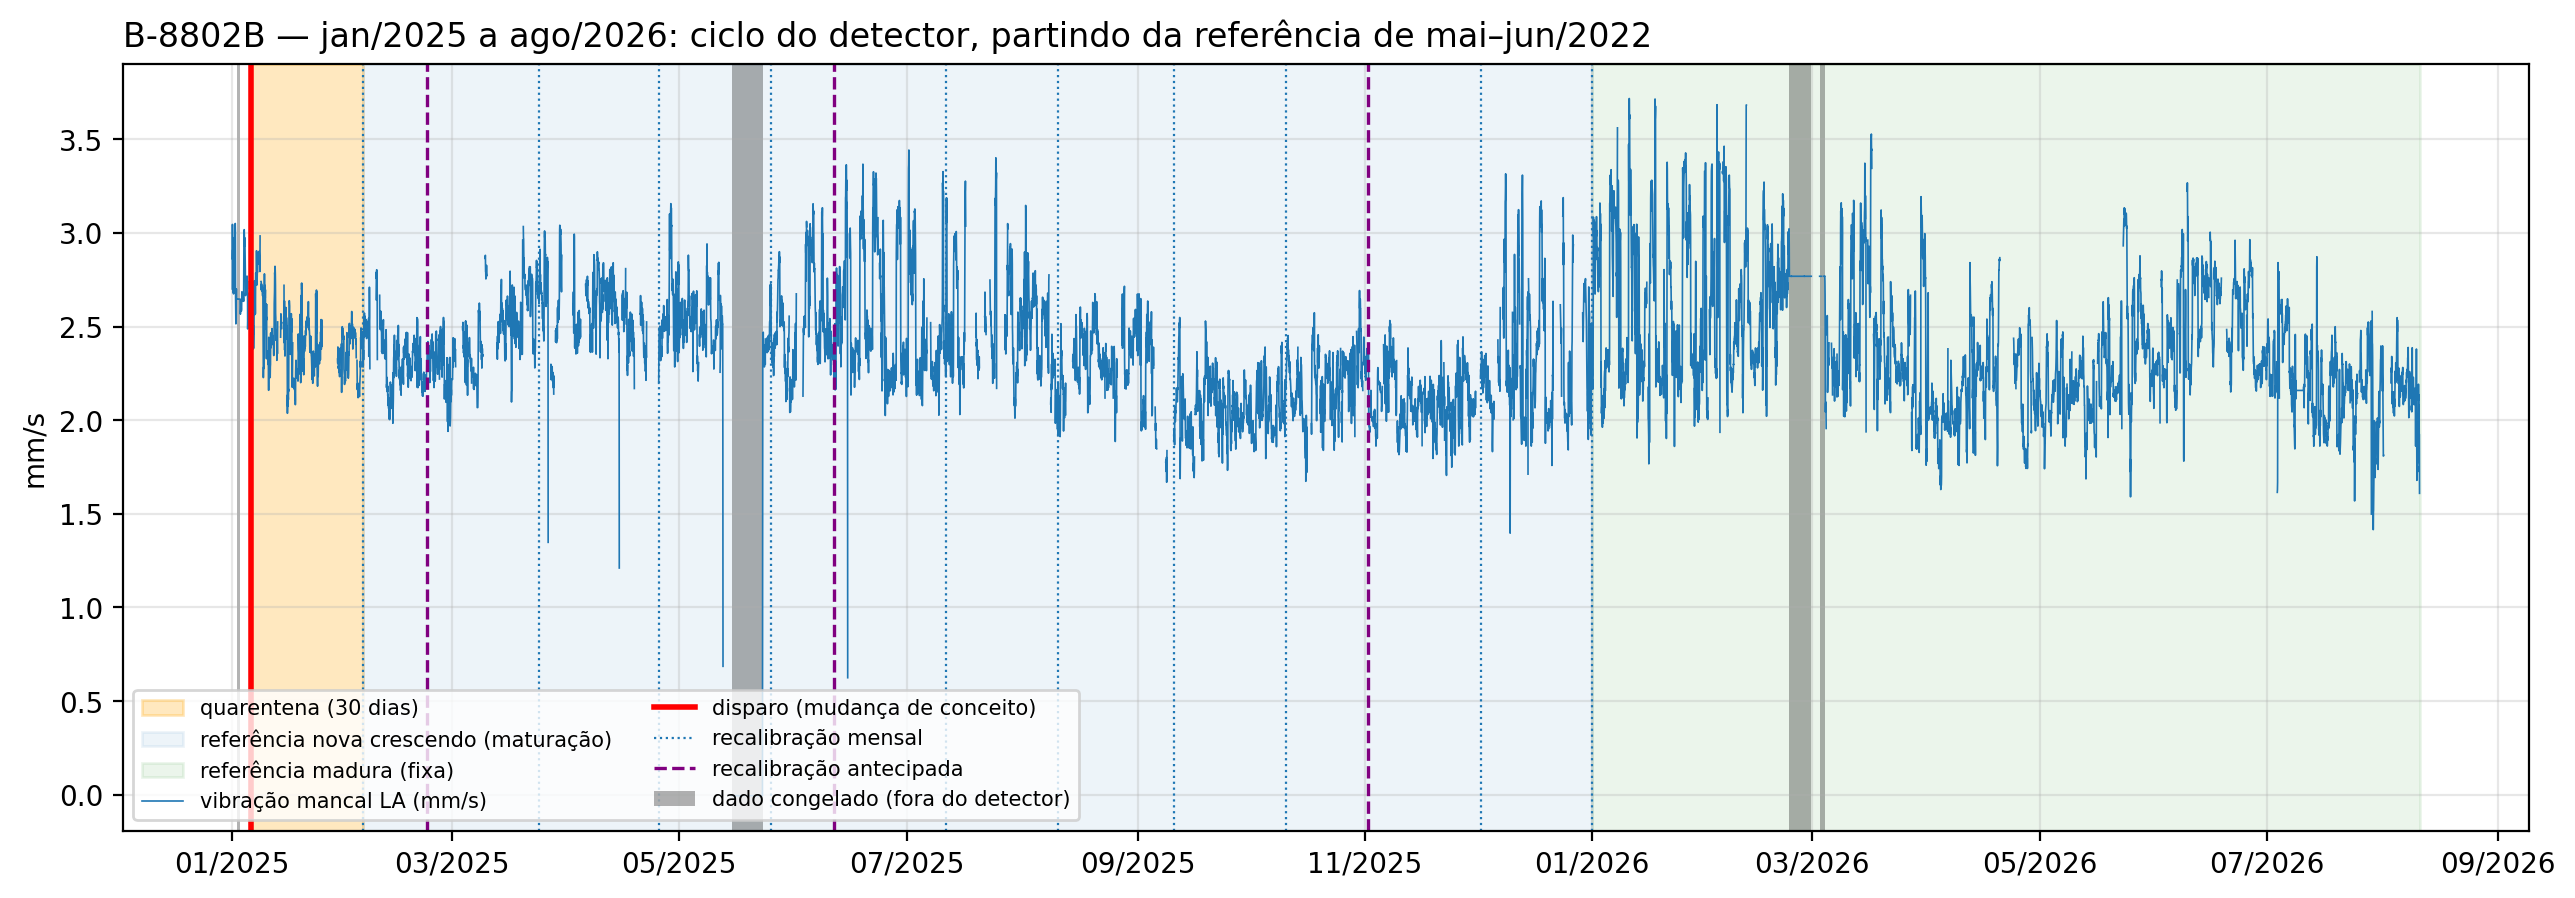

,tipo,instante,sensores,referência
0,calibracao_inicial,15/05/2022,,15/05/2022 a 20/06/2022
1,deteccao,06/01/2025,"Pressão Descarga, Vibração Bomba LA",
2,recalibracao,05/02/2025,,06/01/2025 a 05/02/2025
3,recalibracao_antecipada,22/02/2025,"Pressão Sucção, Vibração Bomba LNA",06/01/2025 a 22/02/2025
4,recalibracao,24/03/2025,,06/01/2025 a 24/03/2025
5,recalibracao,25/04/2025,,06/01/2025 a 22/04/2025
6,recalibracao,25/05/2025,,06/01/2025 a 25/05/2025
7,recalibracao_antecipada,11/06/2025,Vibração Bomba LNA,06/01/2025 a 11/06/2025
8,recalibracao,11/07/2025,,06/01/2025 a 11/07/2025
9,recalibracao,10/08/2025,,06/01/2025 a 10/08/2025


In [5]:
res = simular_ciclo(serie, ref22, window_size=288)
ev = res.eventos
det_ev = ev[ev["tipo"] == "deteccao"]; rec = ev[ev["tipo"] == "recalibracao"]; ant = ev[ev["tipo"] == "recalibracao_antecipada"]
madura = rec["instante"].max(); d1 = det_ev["instante"].iloc[0]

h = serie_bruta["Vibração Bomba LA"].resample("1h").mean()
fig, ax = plt.subplots(figsize=(13, 4.6))
ax.axvspan(d1, d1 + pd.Timedelta(days=30), color="orange", alpha=0.25, label="quarentena (30 dias)")
ax.axvspan(d1 + pd.Timedelta(days=30), madura, color="tab:blue", alpha=0.08, label="referência nova crescendo (maturação)")
ax.axvspan(madura, serie.index.max(), color="green", alpha=0.08, label="referência madura (fixa)")
ax.plot(h.index, h, linewidth=0.6, color="tab:blue", label="vibração mancal LA (mm/s)")
for n, t in enumerate(det_ev["instante"]):
    ax.axvline(t, color="red", linewidth=2, label="disparo (mudança de conceito)" if n == 0 else None)
for n, t in enumerate(rec["instante"]):
    ax.axvline(t, color="tab:blue", linewidth=0.8, linestyle=":", label="recalibração mensal" if n == 0 else None)
for n, t in enumerate(ant["instante"]):
    ax.axvline(t, color="purple", linewidth=1.2, linestyle="--", label="recalibração antecipada" if n == 0 else None)
for n, (a, b) in enumerate(CONGELADOS):
    ax.axvspan(a, b, color="black", alpha=0.3, linewidth=0, label="dado congelado (fora do detector)" if n == 0 else None)
ax.set_ylabel("mm/s"); ax.grid(alpha=0.3); ax.legend(loc="lower left", fontsize=7.5, ncol=2)
ax.set_title("B-8802B — jan/2025 a ago/2026: ciclo do detector, partindo da referência de mai–jun/2022", loc="left")
ax.xaxis.set_major_formatter(mdates.DateFormatter("%m/%Y")); plt.tight_layout(); plt.show()

tab = ev.assign(sensores=ev["sensores"].map(lambda s: ", ".join(s) if isinstance(s, list) else ""),
                referência=[f"{a:%d/%m/%Y} a {b:%d/%m/%Y}" if pd.notna(a) else "" for a, b in zip(ev["ref_inicio"], ev["ref_fim"])])
tab["instante"] = tab["instante"].dt.strftime("%d/%m/%Y")
tab[["tipo", "instante", "sensores", "referência"]]

**Leitura.**
- **06/01/2025:** o disparo da mudança de conceito real, o mesmo da seção 3. Depois de 30 dias de quarentena a referência passa a ser
  o dado desde o disparo e cresce todo mês.
- **Recalibrações antecipadas** durante a maturação: a referência de poucos meses ainda não cobre todos os regimes
  de pressão e vibração, então quando aparece um regime novo ela é refeita antes do prazo. Não é mudança de
  conceito, é a referência aprendendo o ano.
- **jan/2026:** a referência chega a ~12 meses e fica fixa, a mesma janela com que o modelo atual foi treinado.
- **2026:** nenhum disparo. Sem o tratamento do dado congelado, esta mesma simulação dava um disparo falso em
  08/08/2026 e uma recalibração antecipada causada pelo congelamento de maio/2025, que entrava na referência.

## 5. Com o modelo atual: o que o KS viu em 2025–26

O detector do modelo atual é calibrado com 2025 inteiro, o período do treino. Abaixo, ele calibrado do jeito que o
monitor faz agora (sem o dado congelado, quantis, reset em paradas longas), varrendo 2025–26. A figura mostra a
temperatura do mancal LA, o sensor que mais se aproximou do limite.

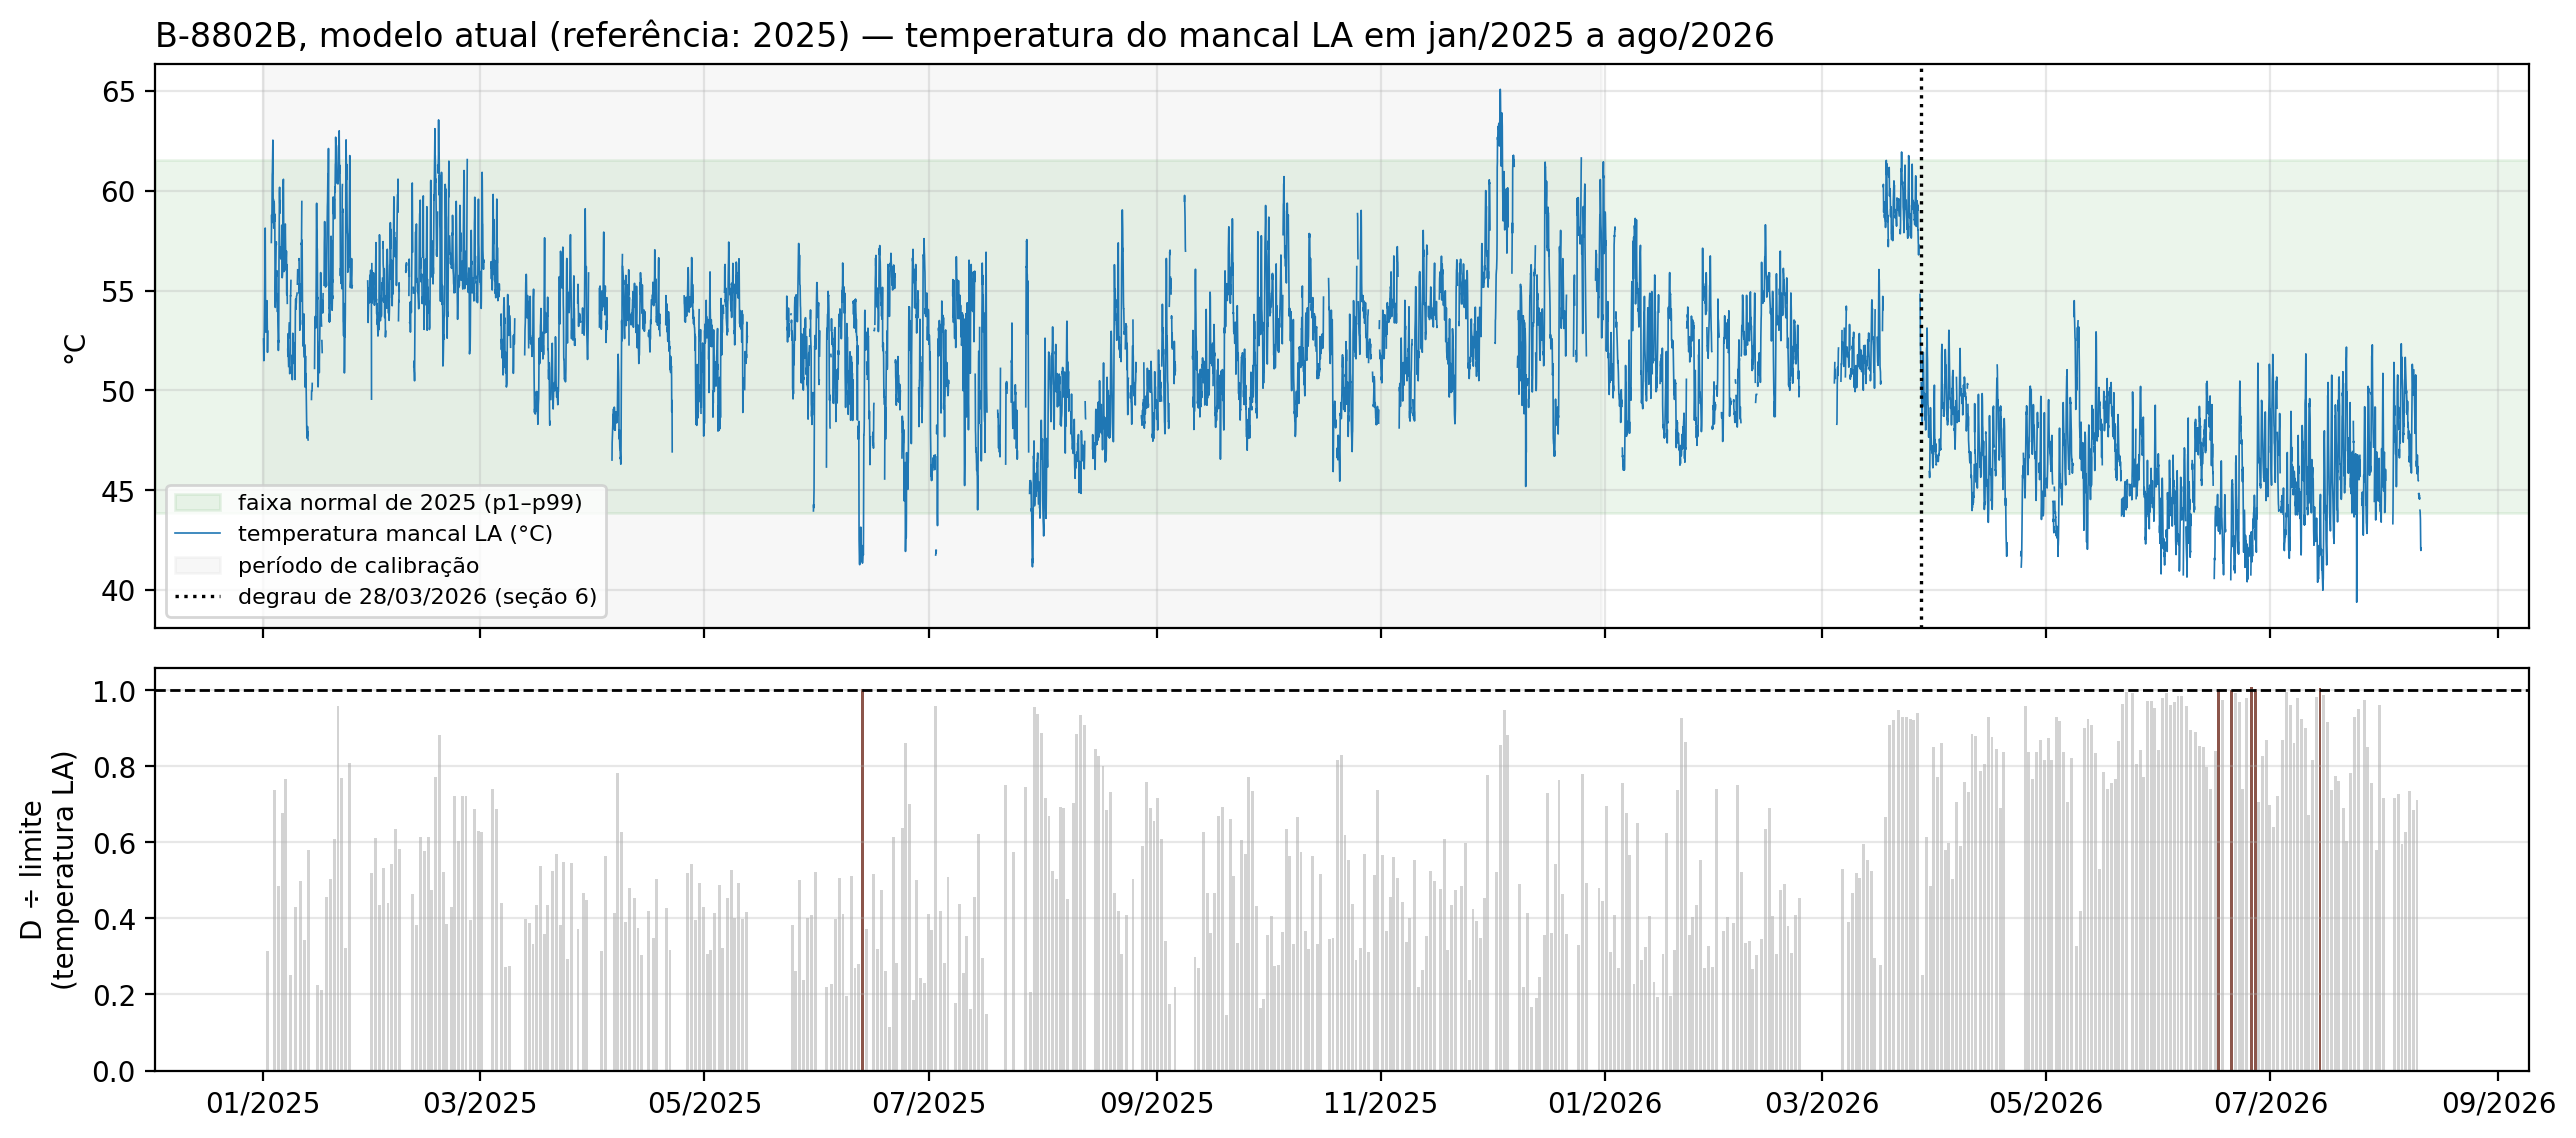

,Pressão Sucção,Pressão Descarga,Vibração Bomba LA,Vibração Bomba LNA,Temperatura Bomba LA,disparos
calibração,,,,,,
"como está no pacote hoje (sorteio, com dado congelado)",0.980,0.961,0.975,0.975,0.982,19/05/2025 (Vibração Bomba LNA); 22/05/2025 (V...
"como o monitor calibra agora (quantis, sem dado congelado)",0.981,0.963,0.856,0.692,0.983,nenhum


In [6]:
serie_atual_bruta =mon._temporal_steps(B_ATUAL, raw)[COLS]
serie_atual = serie_atual_bruta[~si.frozen_mask(serie_atual_bruta).to_numpy()]
det_atual = CalibratedKSDetector(serie_atual.loc[:"2025-12-31"], window_size=288, n_reference=mon.M6_NREF, sampling="quantile")
d_atual, disp_atual = det_atual.scan(serie_atual, reset_gap=mon.M6_RESET_GAP)
det_pacote = CalibratedKSDetector.from_drift_ref(B_ATUAL / "drift_ref.json")     # como está no bundle hoje
_, disp_pacote = det_pacote.scan(serie_atual_bruta)
c = "Temperatura Bomba LA"
s25 = serie_atual.loc[:"2025-12-31"]; lo, hi = s25[c].quantile([0.01, 0.99])
h = serie_atual[c].resample("1h").mean().asfreq("1h")
r = (d_atual / np.asarray(det_atual.d_crit))[c]
fig, axes = plt.subplots(2, 1, figsize=(13, 5.8), sharex=True, gridspec_kw={"height_ratios": [1.4, 1]})
axes[0].axhspan(lo, hi, color="green", alpha=0.08, label="faixa normal de 2025 (p1–p99)")
axes[0].plot(h.index, h, linewidth=0.6, label="temperatura mancal LA (°C)")
axes[0].axvspan(pd.Timestamp("2025-01-01"), pd.Timestamp("2025-12-31"), color="gray", alpha=0.06, label="período de calibração")
axes[0].axvline(pd.Timestamp("2026-03-28"), color="black", linestyle=":", linewidth=1.2, label="degrau de 28/03/2026 (seção 6)")
axes[1].bar(r.index, r, width=0.8, color=["tab:brown" if v > 1 else "lightgray" for v in r])
axes[1].axhline(1, color="black", linestyle="--", linewidth=1)
axes[0].set_ylabel("°C"); axes[0].grid(alpha=0.3); axes[0].legend(loc="lower left", fontsize=8)
axes[0].set_title("B-8802B, modelo atual (referência: 2025) — temperatura do mancal LA em jan/2025 a ago/2026", loc="left")
axes[1].set_ylabel("D ÷ limite\n(temperatura LA)"); axes[1].grid(alpha=0.3, axis="y")
axes[1].xaxis.set_major_formatter(mdates.DateFormatter("%m/%Y")); plt.tight_layout(); plt.show()

fmt = lambda f: "; ".join(f"{t:%d/%m/%Y} ({', '.join(s)})" for t, s in f) or "nenhum"
pd.DataFrame([
    {"calibração": "como está no pacote hoje (sorteio, com dado congelado)",
     **{k: round(v, 3) for k, v in zip(det_pacote.feature_names, det_pacote.d_crit)}, "disparos": fmt(disp_pacote)},
    {"calibração": "como o monitor calibra agora (quantis, sem dado congelado)",
     **{k: round(v, 3) for k, v in zip(det_atual.feature_names, det_atual.d_crit)}, "disparos": fmt(disp_atual)},
]).set_index("calibração")

**Leitura.**
- **Sem o dado congelado, o limite das vibrações cai** de 0,975 para ~0,86 (LA) e ~0,69 (LNA): o detector fica
  mais sensível nelas. Os disparos de maio/2025 do pacote eram o dado congelado e viram aviso M7.
- **O KS na série bruta não pega a mudança de 2026 de forma robusta.** A barra da temperatura fica rente ao limite
  (0,97 a 1,01) de abril a julho. O pacote de hoje dispara em 27/06; a calibração nova, não: com a barra a 1 % do
  limite, o resultado depende do alinhamento das janelas. A seção 6 mostra que a mudança começou em 28/03/2026 e por
  que a estação esconde ela do KS.
- A recalibração do bundle é 1 comando (`scripts/monitor_drift.py --make-drift-ref`, que agora usa quantis e tira o
  dado congelado), a fazer na próxima entrega do pacote.

## 6. A temperatura do mancal LA em 2026: estação ou mudança?

Olhando só a série bruta, 2026 parece um inverno mais frio: em 2025 o mancal também esfriou em jul–ago. Para separar
estação de mudança, olhamos três coisas: o ano de 2025 mês a mês, um **modelo de comportamento normal** que desconta a
estação, e os dias em que o nível mudou.

**1. A estação.** Em 2025 todas as temperaturas descem uns 6 °C no inverno e voltam em dezembro, juntas. Em 2026 o
motor segue o mesmo caminho de 2025; o mancal LA, não.

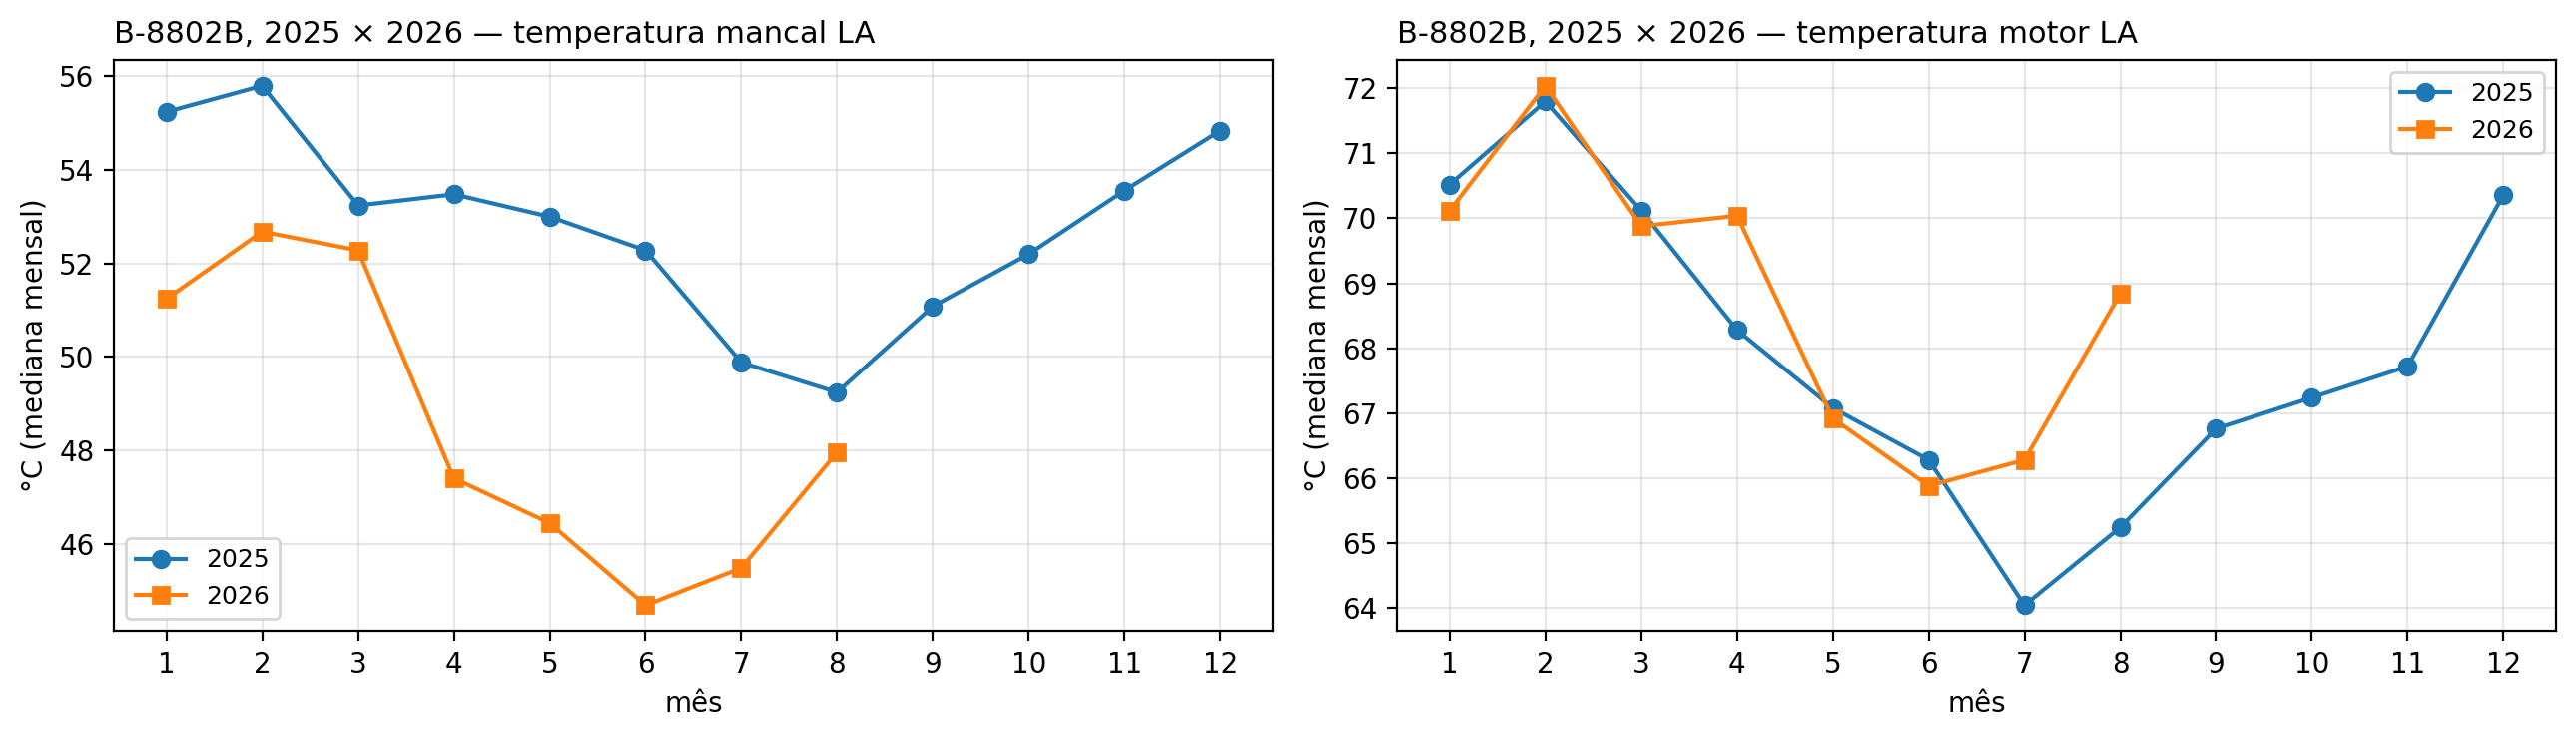

mês,1,2,3,4,5,6,7,8
2026 − 2025 (°C),,,,,,,,
Temperatura Bomba LA,-4.0,-3.1,-1.0,-6.1,-6.6,-7.6,-4.4,-1.3
Temperatura Motor LA,-0.4,0.2,-0.2,1.8,-0.2,-0.4,2.2,3.6
Temperatura Motor LNA,-0.2,0.0,0.2,2.8,2.1,2.2,4.2,5.0


In [7]:
opd = raw[raw["Pressão Descarga"] > 35]
opd = opd[~si.frozen_mask(opd).to_numpy()]
mes = opd.groupby([opd.index.year, opd.index.month]).median()
fig, axes = plt.subplots(1, 2, figsize=(13, 3.8), sharey=False)
for ax, c in zip(axes, ["Temperatura Bomba LA", "Temperatura Motor LA"]):
    for ano, estilo in [(2025, "-o"), (2026, "-s")]:
        s = mes.loc[ano, c]; ax.plot(s.index, s.values, estilo, label=str(ano))
    ax.set_xticks(range(1, 13)); ax.set_xlabel("mês"); ax.set_ylabel("°C (mediana mensal)"); ax.grid(alpha=0.3)
    ax.set_title(f"B-8802B, 2025 × 2026 — {c.replace('Bomba', 'mancal').replace('Motor', 'motor').replace('Temperatura', 'temperatura')}", loc="left", fontsize=11); ax.legend(fontsize=9)
plt.tight_layout(); plt.show()
dif = (mes.loc[2026] - mes.loc[2025].loc[mes.loc[2026].index])[["Temperatura Bomba LA", "Temperatura Motor LA", "Temperatura Motor LNA"]]
dif.index.name = "mês"; dif.round(1).T.rename_axis("2026 − 2025 (°C)")

**2. O modelo de comportamento normal.** Ajustamos em 2025 uma regressão que prevê a temperatura do mancal LA a
partir das temperaturas do motor e das pressões, que sobem e descem com a mesma estação e a mesma carga. O que sobra
(o **resíduo** = medido − previsto) é o que a estação e a operação **não** explicam. Em 2025 ele fica perto de zero o
ano todo; se o mancal mudar, o resíduo muda.

In [8]:
from sklearn.linear_model import LinearRegression
passos = [s for s in json.loads((B_ATUAL / "pipeline.json").read_text())
          if s["step"] in si._STEPS_TEMPORAIS and s["step"] != "select_features"]
todos = raw
for st in passos: todos = si._STEPS_TEMPORAIS[st["step"]](todos, **{k: v for k, v in st.items() if k != "step"})
todos = todos[~si.frozen_mask(todos).to_numpy()]                 # 8 sensores, bomba operando, sem dado congelado
XR = ["Temperatura Motor LA", "Temperatura Motor LNA", "Pressão Descarga", "Pressão Sucção"]
nbm = LinearRegression().fit(todos.loc["2025", XR], todos.loc["2025", "Temperatura Bomba LA"])
residuo = todos["Temperatura Bomba LA"] - nbm.predict(todos[XR])
cont = residuo.resample("1D").count()
res_d = residuo.resample("1D").median()[cont >= 144]            # mediana diária, dias com ≥ 12 h de operação
print(f"R² em 2025: {nbm.score(todos.loc['2025', XR], todos.loc['2025', 'Temperatura Bomba LA']):.2f}; "
      f"o resíduo diário em 2025 tem desvio padrão de {res_d.loc['2025'].std():.1f} °C")
r_mes = residuo.groupby([residuo.index.year, residuo.index.month]).median().unstack(0).round(1)
r_mes.index.name = "mês"; r_mes.columns.name = "resíduo (°C)"; r_mes.T

R² em 2025: 0.61; o resíduo diário em 2025 tem desvio padrão de 1.8 °C


mês,1,2,3,4,5,6,7,8,9,10,11,12
resíduo (°C),,,,,,,,,,,,
2025,1.1,0.6,-1.1,0.2,0.7,0.7,0.1,-1.5,-0.6,0.0,0.7,-0.0
2026,-3.1,-3.0,-0.7,-6.5,-5.3,-6.5,-6.2,-4.9,NaN,NaN,NaN,NaN


**3. Os dias da mudança.** O resíduo de 2026 tem dois degraus bruscos, e os dois caem **exatamente em paradas da
bomba**: nos dias 17/03 e 27/03/2026 ela parou por algumas horas e voltou em outro patamar. As temperaturas do motor
não mudam. Na 2ª parada as vibrações também mudam de nível.

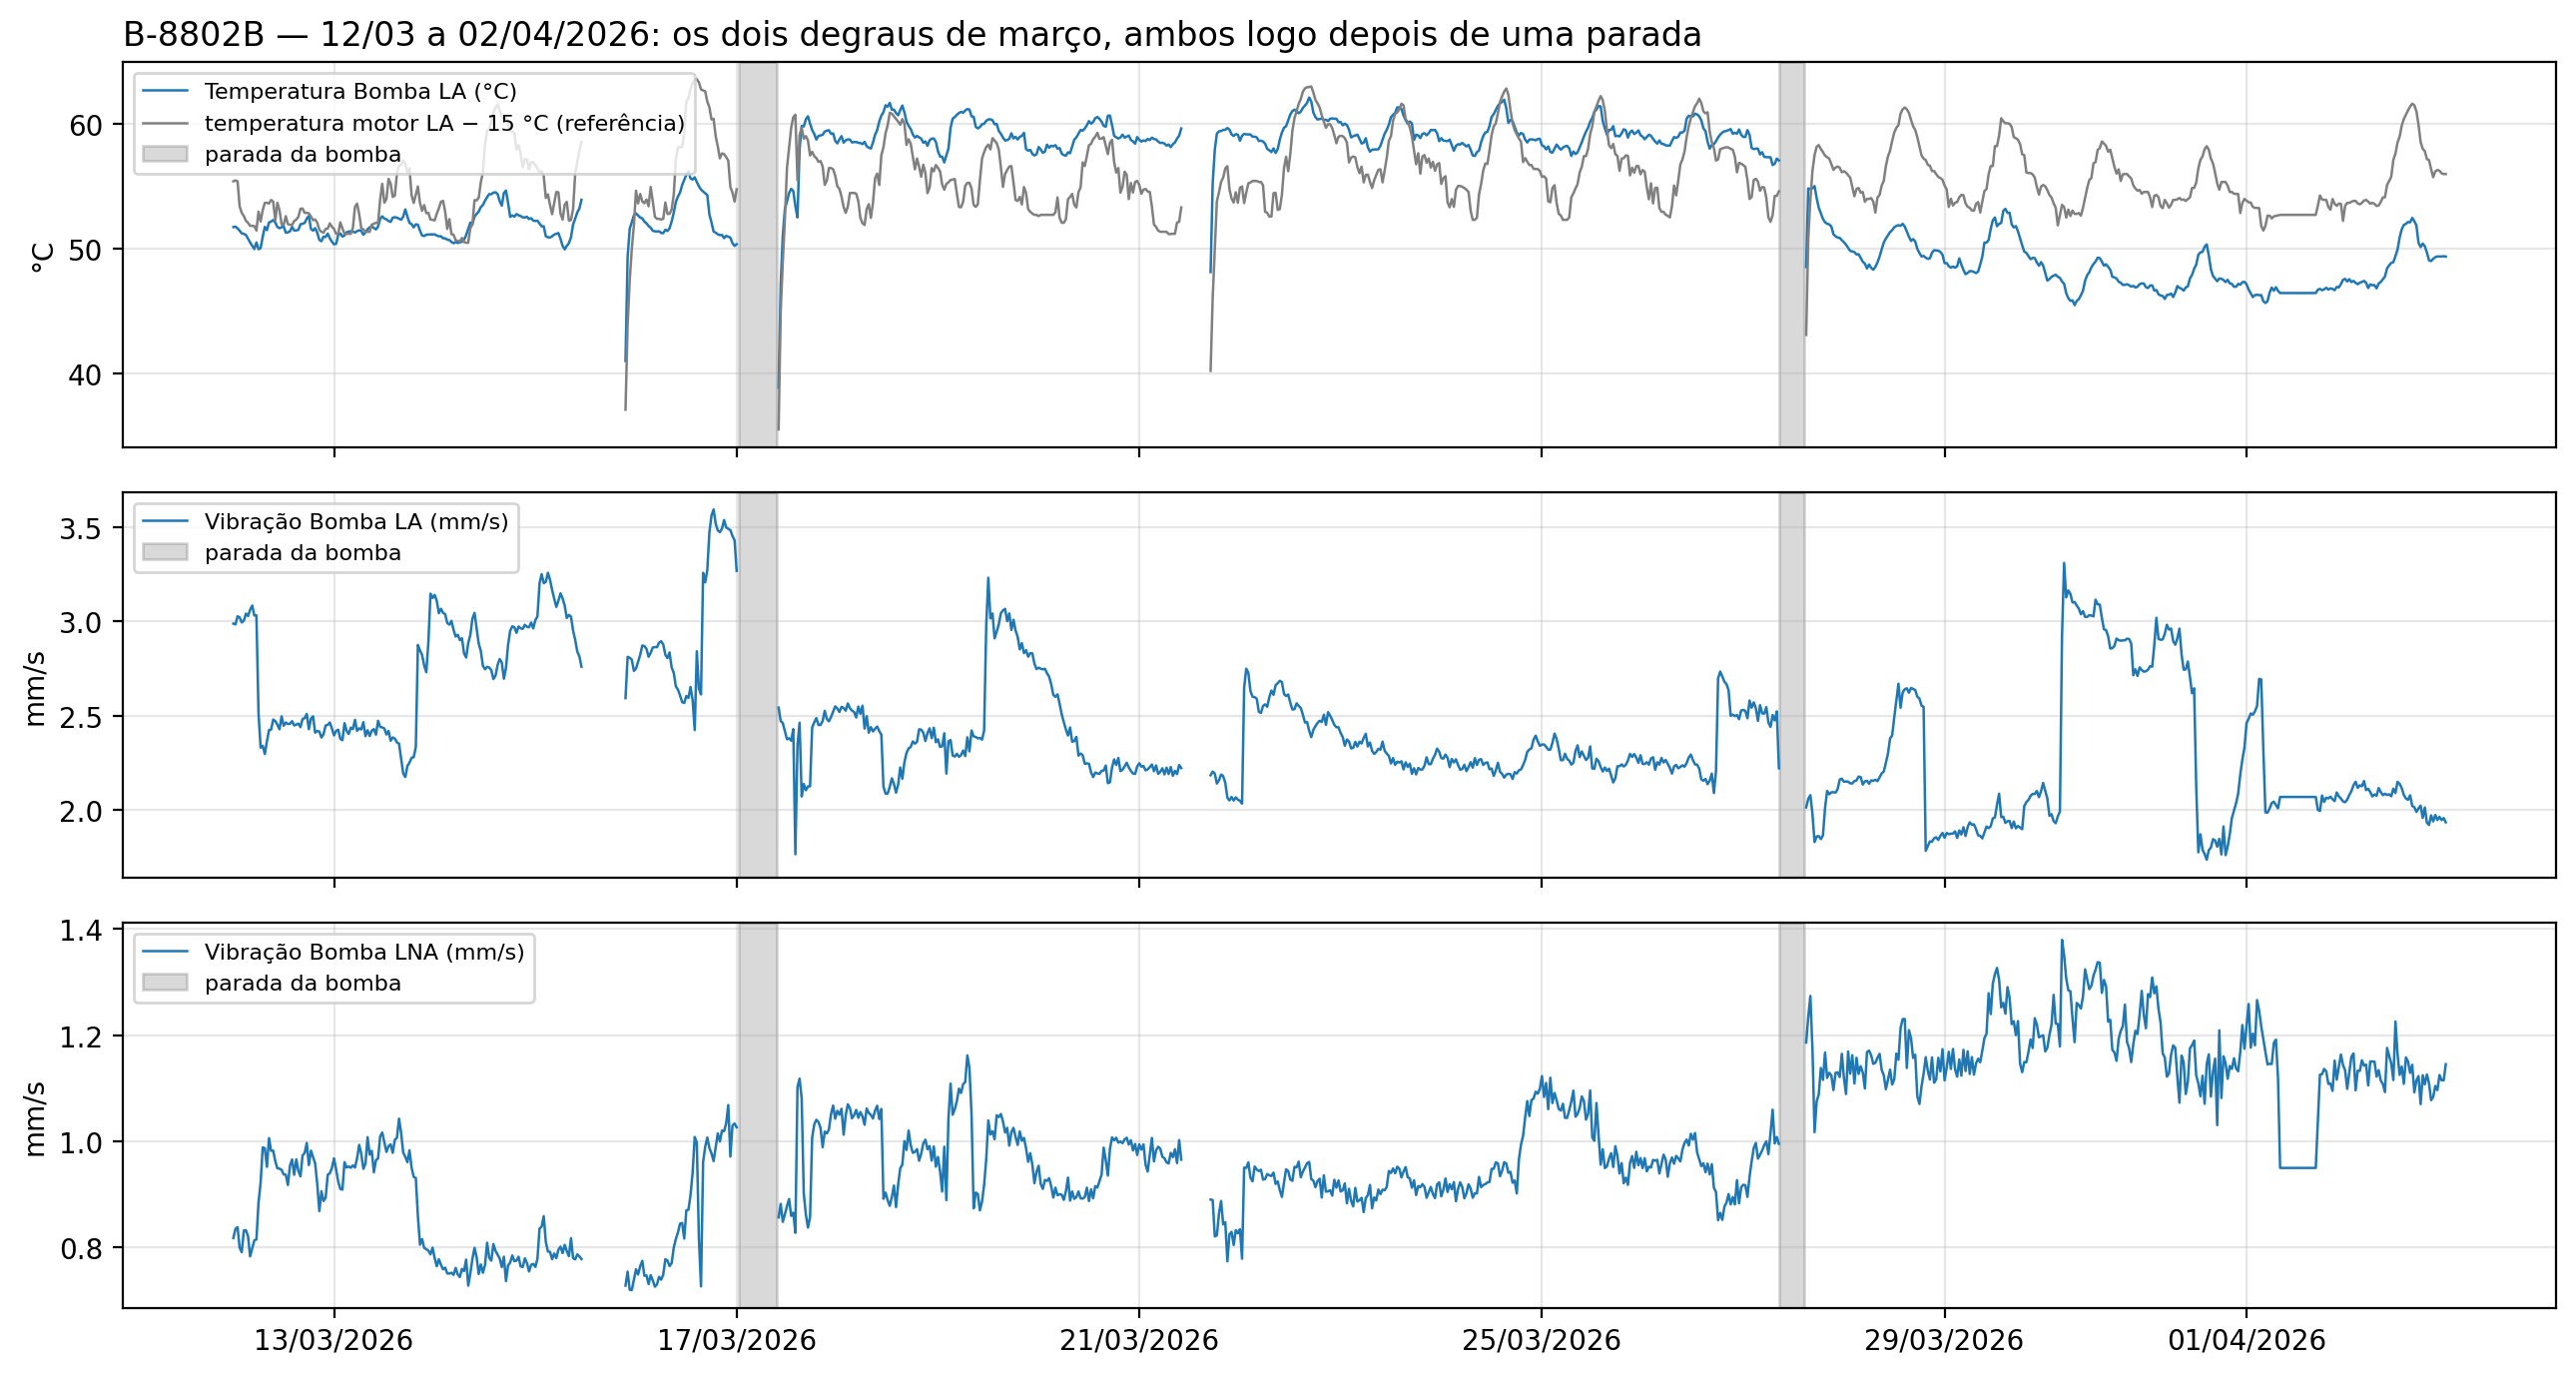

parada 2026-03-17: mancal LA 52.1 → 58.8 °C; vibração LA 2.98 → 2.52; vibração LNA 0.83 → 0.98 mm/s; motor LA 71.1 → 70.3 °C
parada 2026-03-27: mancal LA 59.1 → 49.5 °C; vibração LA 2.34 → 2.07; vibração LNA 0.98 → 1.22 mm/s; motor LA 71.7 → 70.8 °C


In [9]:
PARADAS = [("2026-03-17 00:30", "2026-03-17 09:30"), ("2026-03-27 08:30", "2026-03-27 14:30")]
ini, fim = "2026-03-12", "2026-04-02"
hz = raw.loc[ini:fim].resample("30min").mean()
painel = [("Temperatura Bomba LA", "°C"), ("Vibração Bomba LA", "mm/s"), ("Vibração Bomba LNA", "mm/s")]
fig, axes = plt.subplots(3, 1, figsize=(13, 7), sharex=True)
for ax, (c, u) in zip(axes, painel):
    x = hz[c].where(hz["Pressão Descarga"] > 35)
    ax.plot(x.index, x, linewidth=0.9, label=f"{c} ({u})")
    if c == "Temperatura Bomba LA":
        ax.plot(hz.index, hz["Temperatura Motor LA"].where(hz["Pressão Descarga"] > 35) - 15, linewidth=0.9,
                color="gray", label="temperatura motor LA − 15 °C (referência)")
    for n, (a, b) in enumerate(PARADAS):
        ax.axvspan(pd.Timestamp(a), pd.Timestamp(b), color="black", alpha=0.15, label="parada da bomba" if n == 0 else None)
    ax.set_ylabel(u); ax.grid(alpha=0.3); ax.legend(loc="upper left", fontsize=8)
axes[0].set_title("B-8802B — 12/03 a 02/04/2026: os dois degraus de março, ambos logo depois de uma parada", loc="left")
axes[-1].xaxis.set_major_formatter(mdates.DateFormatter("%d/%m/%Y")); plt.tight_layout(); plt.show()
for a, b in PARADAS:
    antes = todos.loc[pd.Timestamp(a) - pd.Timedelta(days=3):a]; depois = todos.loc[b:pd.Timestamp(b) + pd.Timedelta(days=3)]
    print(f"parada {a[:10]}: mancal LA {antes['Temperatura Bomba LA'].median():.1f} → {depois['Temperatura Bomba LA'].median():.1f} °C; "
          f"vibração LA {antes['Vibração Bomba LA'].median():.2f} → {depois['Vibração Bomba LA'].median():.2f}; "
          f"vibração LNA {antes['Vibração Bomba LNA'].median():.2f} → {depois['Vibração Bomba LNA'].median():.2f} mm/s; "
          f"motor LA {antes['Temperatura Motor LA'].median():.1f} → {depois['Temperatura Motor LA'].median():.1f} °C")

### 6.1 Um detector que desconta a estação

Se a mudança começou em 28/03, por que o KS não a pegou? Porque ele compara **um dia** com **o ano inteiro de 2025**,
verão e inverno juntos. Um dia ocupa uma faixa estreita de temperatura, então todo dia já parece "diferente" do ano,
e o limite vai para ~0,98, quase o máximo. Um degrau de −10 °C em março, ainda no calor, cai dentro da faixa do ano.

O detector novo (`ResidualLevelDetector`, em `src/transpetro_modelos/drift/residuo.py`) usa o resíduo do modelo de
comportamento normal, que já não tem estação, e uma regra simples de nível: **mediana diária do resíduo fora da faixa
p0,5–p99,5 das medianas diárias da referência, em 3 dos últimos 5 dias com operação**.

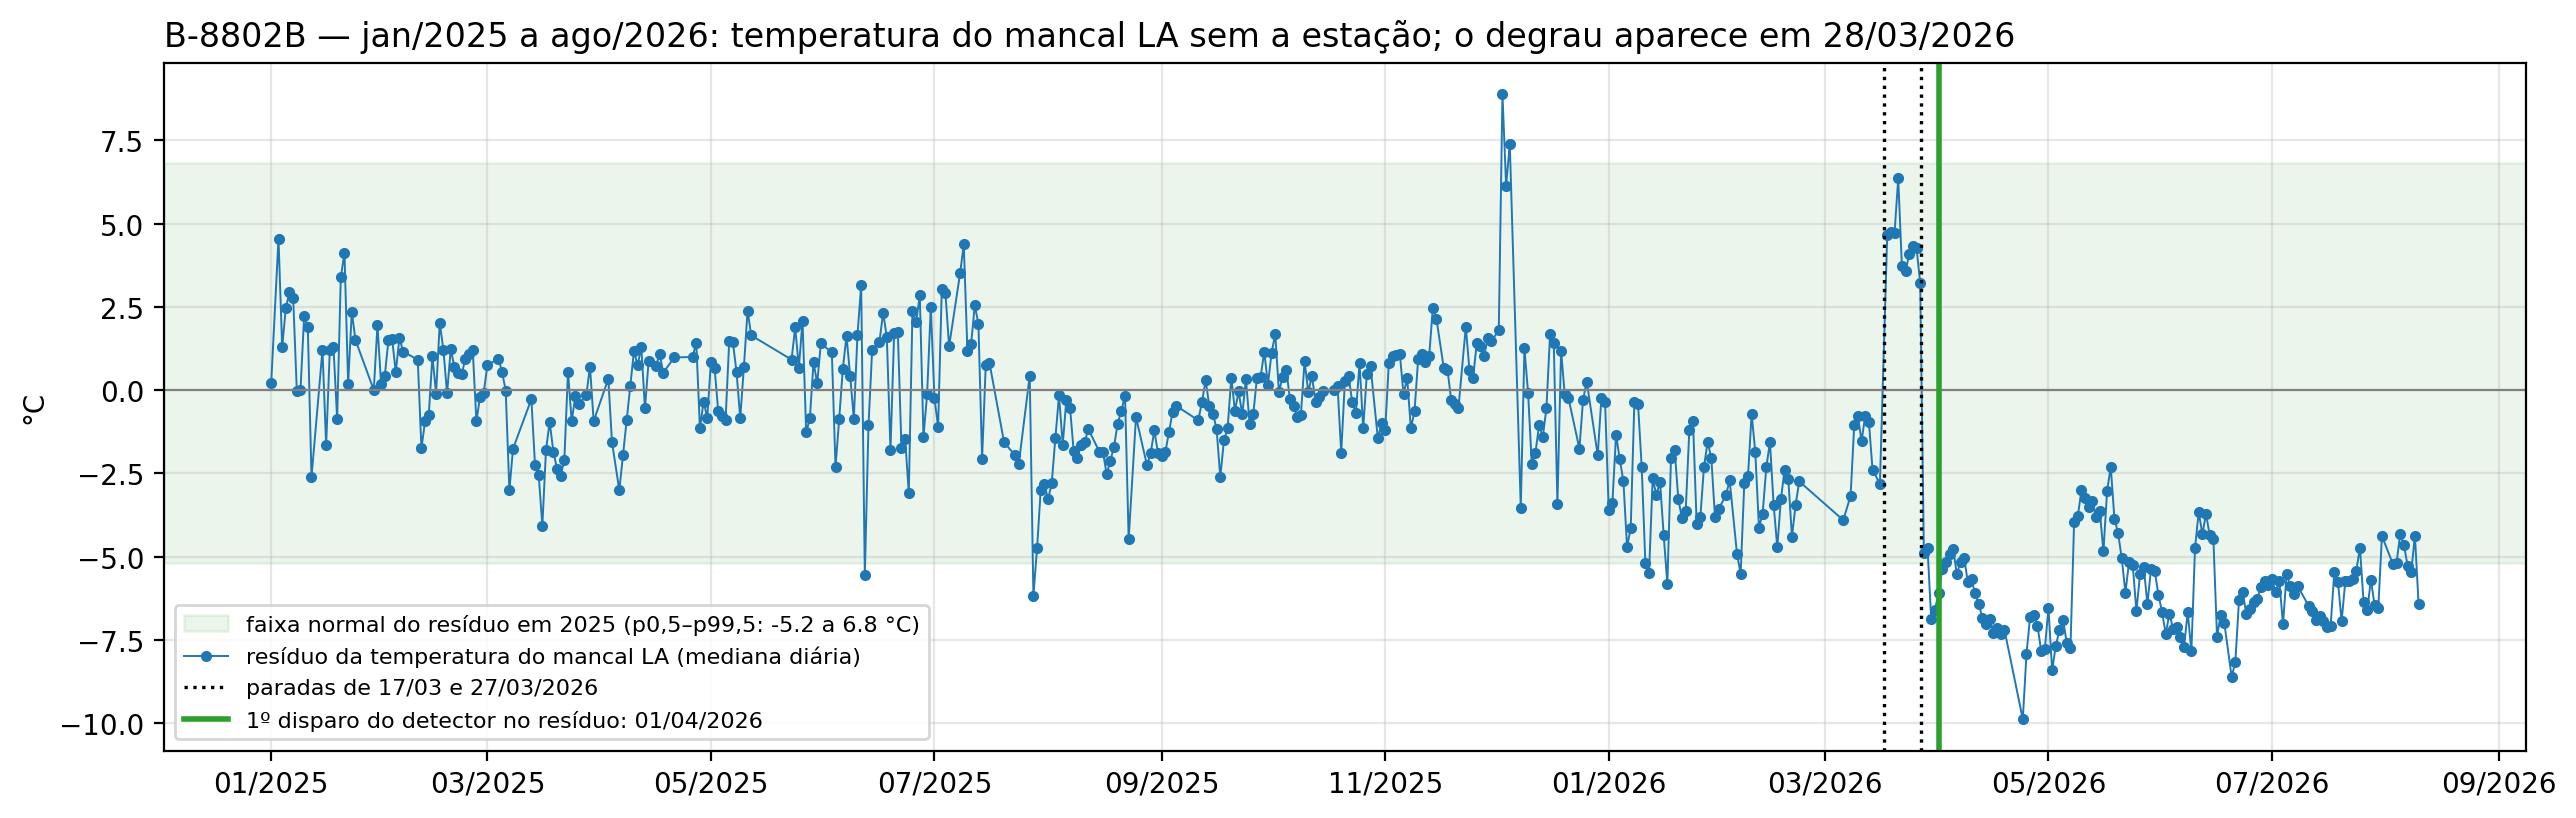

,disparos em 2025,jan a 16/03/2026 (sem mudança),1º disparo depois de 28/03/2026
detector,,,
"KS na série bruta, pacote de hoje",0,0,27/06/2026
"KS na série bruta, calibração nova",0,0,nenhum
nível no resíduo,0,0,01/04/2026


mancal LA: R² 0.61, faixa -5.2 a 6.8 °C | mancal LNA (ajustado depois do degrau de 07/04/2025): R² 0.32, faixa -5.9 a 22.4 °C


In [10]:
det_res = ResidualLevelDetector("Temperatura Bomba LA", XR).fit(todos.loc["2025"])
res_d, disp_nivel = det_res.scan(todos)
faixa = det_res.band
fig, ax = plt.subplots(figsize=(13, 4.2))
ax.axhspan(*faixa, color="green", alpha=0.08, label=f"faixa normal do resíduo em 2025 (p0,5–p99,5: {faixa[0]:.1f} a {faixa[1]:.1f} °C)")
ax.plot(res_d.index, res_d, marker=".", linewidth=0.7, label="resíduo da temperatura do mancal LA (mediana diária)")
ax.axhline(0, color="gray", linewidth=0.8)
for n, (a, b) in enumerate(PARADAS):
    ax.axvline(pd.Timestamp(a), color="black", linestyle=":", linewidth=1.2, label="paradas de 17/03 e 27/03/2026" if n == 0 else None)
d1 = [t for t in disp_nivel if t.year == 2026][0]
ax.axvline(d1, color="tab:green", linewidth=2, label=f"1º disparo do detector no resíduo: {d1:%d/%m/%Y}")
ax.set_ylabel("°C"); ax.grid(alpha=0.3); ax.legend(loc="lower left", fontsize=8)
ax.set_title("B-8802B — jan/2025 a ago/2026: temperatura do mancal LA sem a estação; o degrau aparece em 28/03/2026", loc="left")
ax.xaxis.set_major_formatter(mdates.DateFormatter("%m/%Y")); plt.tight_layout(); plt.show()

conta = lambda disp, a, b: sum(pd.Timestamp(a) <= t <= pd.Timestamp(b) for t in disp)
primeiro = lambda disp: next((f"{t:%d/%m/%Y}" for t in disp if t >= pd.Timestamp("2026-03-28")), "nenhum")
linhas = []
for nome, ts in [("KS na série bruta, pacote de hoje", [t for t, s in disp_pacote if "Temperatura Bomba LA" in s]),
                 ("KS na série bruta, calibração nova", [t for t, s in disp_atual if "Temperatura Bomba LA" in s]),
                 ("nível no resíduo", disp_nivel)]:
    linhas.append({"detector": nome, "disparos em 2025": conta(ts, "2025-01-01", "2025-12-31"),
                   "jan a 16/03/2026 (sem mudança)": conta(ts, "2026-01-01", "2026-03-16"),
                   "1º disparo depois de 28/03/2026": primeiro(ts)})
display(pd.DataFrame(linhas).set_index("detector"))

# o mesmo detector no outro mancal: a regressão não explica bem a temperatura LNA (degrau em abr/2025 no treino)
det_lna = ResidualLevelDetector("Temperatura Bomba LNA", XR).fit(todos.loc["2025-04-08":"2025-12-31"])
print(f"mancal LA: R² {det_res.r2:.2f}, faixa {faixa[0]:.1f} a {faixa[1]:.1f} °C | mancal LNA (ajustado depois do degrau "
      f"de 07/04/2025): R² {det_lna.r2:.2f}, faixa {det_lna.band[0]:.1f} a {det_lna.band[1]:.1f} °C")

**Leitura.**
- **Há uma mudança, e ela começa em 28/03/2026**, logo depois da parada de 27/03. Descontada a estação, o mancal LA
  passa a operar ~6 °C mais frio do que o comportamento de 2025 previa, e assim fica até agosto. Antes dela, de 17 a
  27/03, houve 10 dias ~4,5 °C **mais quentes**, que começam logo depois da parada de 17/03. As vibrações mudam de
  nível na mesma parada de 27/03; o motor não muda em nenhuma das duas.
- **Antes dos degraus já havia uma deriva lenta:** de jan a meados de março/2026 o resíduo desce aos poucos até uns
  −3 °C (meses 1 e 2 da tabela do resíduo). Pequena demais para disparar qualquer detector sozinha, mas mostra que o
  mancal LA já vinha se afastando do comportamento de 2025 antes de março.
- **O KS na série bruta não a pega de forma robusta:** o pacote de hoje dispara em 27/06, 3 meses depois, quando o
  inverno empurrou a temperatura já deslocada para a ponta de baixo do ano; a calibração nova, nem isso.
- **O detector no resíduo pega a mudança em 4 dias** (01/04/2026), sem nenhum disparo em 2025 nem no começo de 2026.
  Testamos faixas mais estreitas e a regra de 2 em 3 dias: ganham 1 a 2 dias, mas dão 1 disparo falso em dez/2025.
- **A pergunta à operação:** o que foi feito no B-8802B nas paradas de 17/03 (~00:30 às 09:30) e de 27/03/2026
  (~08:30 às 14:30)? Esquentar depois de uma parada e esfriar com as vibrações mudando depois de outra, em horário de
  expediente, tem cara de intervenção (relubrificação, troca de rolamento, alinhamento) ou de troca/recalibração do
  sensor. A resposta decide o caminho: correção mecânica = normal novo (retreino, confirmado); sensor trocado = só
  recalibrar; nada feito = investigar o mancal.

**Ressalvas.** O modelo de comportamento normal precisa explicar bem o sensor. No mancal LA ele explica (R² 0,61). No
mancal LNA, não: a temperatura dele teve um degrau em 07/04/2025, dentro do próprio ano de treino, e mesmo ajustado
só depois do degrau a regressão explica pouco (R² ~0,3) e a faixa normal fica larga demais (de −6 a +22 °C). Esse
mancal continua com o KS. O detector no resíduo está no pacote de drift, mas ainda não no monitor semanal.

### 6.2 E se a referência fosse uma janela deslizante?

Hoje a referência fica **fixa** no período em que o modelo foi treinado (2025). A alternativa é uma **janela deslizante**:
a referência é sempre os últimos 12 meses, refeita todo mês. Ela acompanha a estação sozinha, mas também vai
incorporando o que acontece com o equipamento. Testamos as duas em 2026, nos dois detectores (KS na série bruta e o
detector no resíduo), mantendo tudo o mais igual: janela de 1 dia, 3 de 5 dias, sem dado congelado.

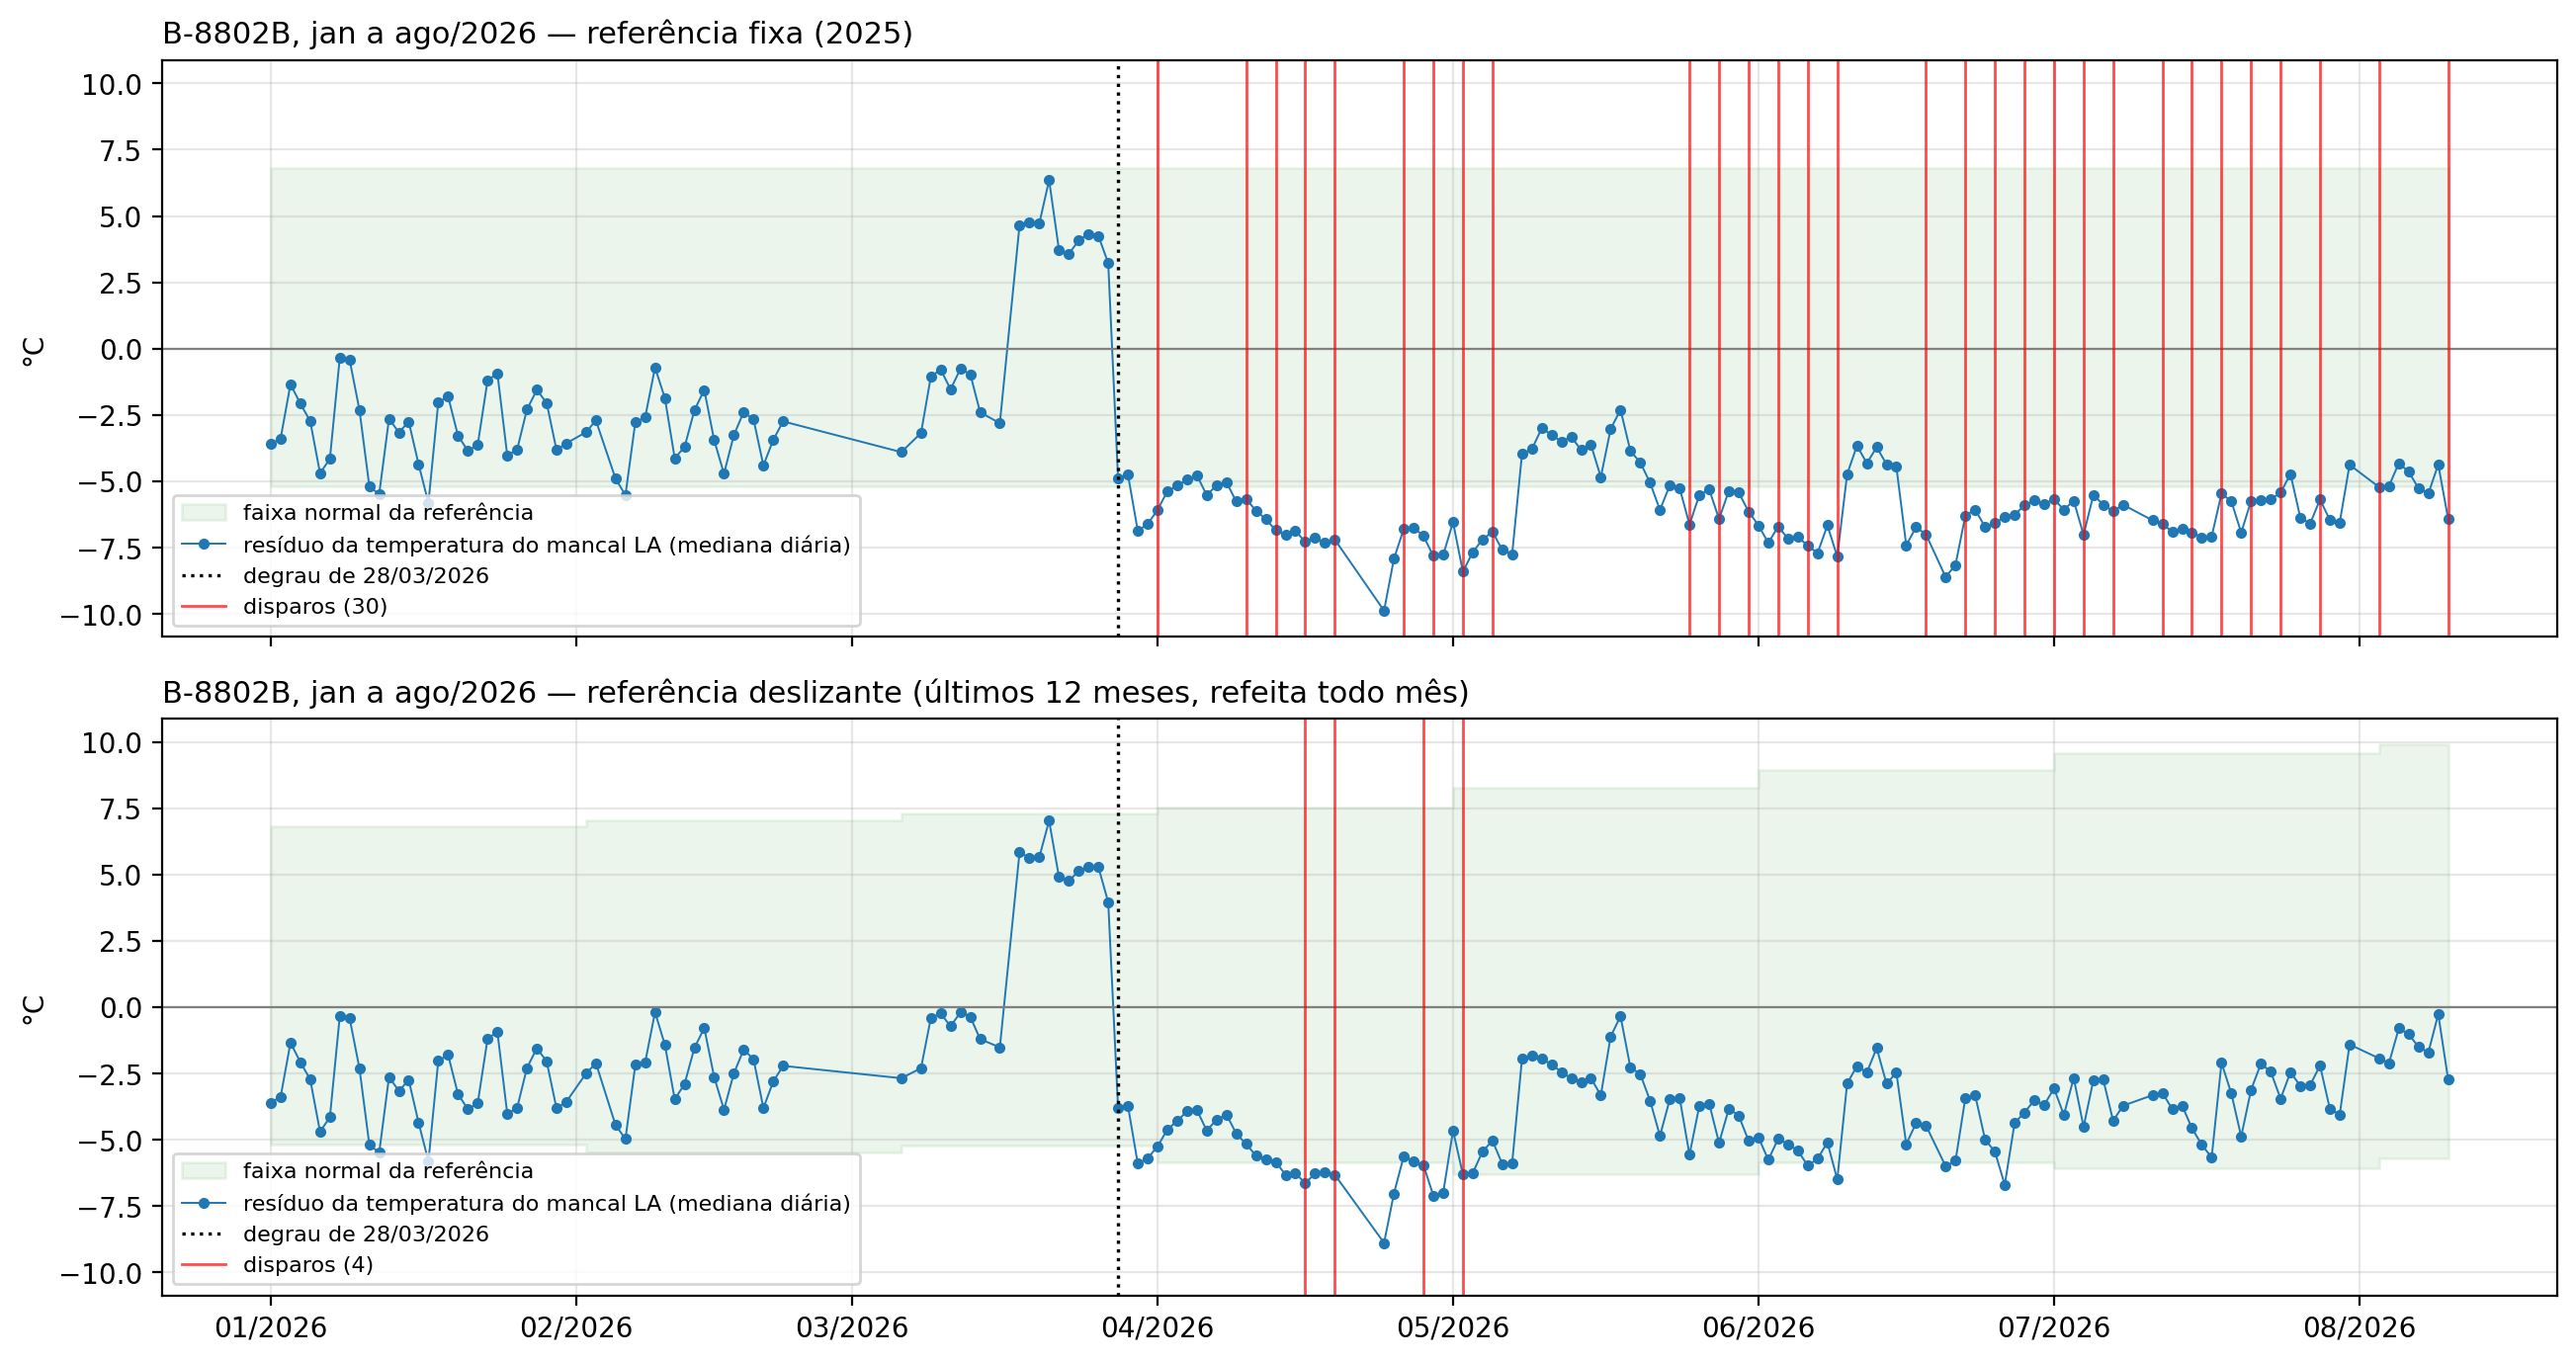

,1º disparo depois de 28/03,último disparo,disparos depois de 28/03
detector,,,
"KS na série bruta, referência fixa (2025)",nenhum,—,0
"KS na série bruta, janela deslizante",nenhum,—,0
"resíduo, referência fixa (2025)",01/04/2026,10/08/2026,30
"resíduo, janela deslizante",16/04/2026,02/05/2026,4


resíduo mensal com a janela deslizante (°C): {1: np.float64(-3.2), 2: np.float64(-2.4), 3: np.float64(-0.2), 4: np.float64(-5.8), 5: np.float64(-3.5), 6: np.float64(-4.9), 7: np.float64(-3.3), 8: np.float64(-1.6)}
com a referência fixa (°C): {1: np.float64(-3.2), 2: np.float64(-3.0), 3: np.float64(-0.8), 4: np.float64(-6.8), 5: np.float64(-5.3), 6: np.float64(-6.7), 7: np.float64(-6.1), 8: np.float64(-5.2)}


In [11]:
MESES = pd.date_range("2026-01-01", "2026-08-01", freq="MS")
fim_mes = lambda m: m + pd.offsets.MonthEnd(1) + pd.Timedelta(hours=23, minutes=55)
um_ano_antes = lambda m: (m - pd.Timedelta(days=365), m - pd.Timedelta(minutes=5))

# KS deslizante: recalibra todo mês com os 365 dias anteriores; a contagem de persistência continua entre meses
disp_ks_desl, det_d = [], None
for m in MESES:
    a, b = um_ano_antes(m)
    novo = CalibratedKSDetector(serie_atual.loc[a:b], window_size=288, n_reference=mon.M6_NREF, sampling="quantile")
    if det_d is not None: novo._runs, novo._buffer = det_d._runs, det_d._buffer
    det_d = novo
    trecho = serie_atual.loc[m:fim_mes(m)]
    for t, x in zip(trecho.index, trecho.to_numpy()):
        if det_d.update(x): disp_ks_desl.append((t, list(det_d.last_drift_features))); det_d.reset()

# resíduo deslizante: regressão e faixa refeitas todo mês com os 365 dias anteriores
def diario(r):
    n = r.resample("1D").count(); return r.resample("1D").median()[n >= 144]
partes, faixas = [], []
for m in MESES:
    a, b = um_ano_antes(m); fit = todos.loc[a:b]
    lr = LinearRegression().fit(fit[XR], fit["Temperatura Bomba LA"])
    lo, hi = diario(fit["Temperatura Bomba LA"] - lr.predict(fit[XR])).quantile([0.005, 0.995])
    seg = todos.loc[m:fim_mes(m)]
    r = diario(seg["Temperatura Bomba LA"] - lr.predict(seg[XR]))
    partes.append(r); faixas.append(pd.DataFrame({"lo": lo, "hi": hi}, index=r.index))
res_desl, faixa_desl = pd.concat(partes), pd.concat(faixas)
fora = (res_desl < faixa_desl["lo"]) | (res_desl > faixa_desl["hi"])
disp_res_desl, hist = [], []
for t, v in fora.items():
    hist = (hist + [bool(v)])[-5:]
    if sum(hist) >= 3: disp_res_desl.append(t); hist = []

lo_f, hi_f = faixa
r26 = res_d.loc["2026"]
fig, axes = plt.subplots(2, 1, figsize=(13, 7), sharex=True, sharey=True)
for ax, (titulo, serie_r, lo_s, hi_s, disp) in zip(axes, [
        ("referência fixa (2025)", r26, pd.Series(lo_f, index=r26.index), pd.Series(hi_f, index=r26.index),
         [t for t in disp_nivel if t.year == 2026]),
        ("referência deslizante (últimos 12 meses, refeita todo mês)", res_desl, faixa_desl["lo"], faixa_desl["hi"], disp_res_desl)]):
    ax.fill_between(lo_s.index, lo_s, hi_s, step="post", color="green", alpha=0.08, label="faixa normal da referência")
    ax.plot(serie_r.index, serie_r, marker=".", linewidth=0.7, label="resíduo da temperatura do mancal LA (mediana diária)")
    ax.axhline(0, color="gray", linewidth=0.8)
    ax.axvline(pd.Timestamp("2026-03-28"), color="black", linestyle=":", linewidth=1.2, label="degrau de 28/03/2026")
    for n, t in enumerate(disp):
        ax.axvline(t, color="red", linewidth=1, alpha=0.7, label=f"disparos ({len(disp)})" if n == 0 else None)
    ax.set_ylabel("°C"); ax.grid(alpha=0.3); ax.legend(loc="lower left", fontsize=8)
    ax.set_title(f"B-8802B, jan a ago/2026 — {titulo}", loc="left", fontsize=11)
axes[-1].xaxis.set_major_formatter(mdates.DateFormatter("%m/%Y")); plt.tight_layout(); plt.show()

depois = lambda ts: [t for t in ts if t >= pd.Timestamp("2026-03-28")]
disp_ks_fixo = disp_atual
linhas = []
for nome, ts in [("KS na série bruta, referência fixa (2025)", [t for t, _ in disp_ks_fixo]),
                 ("KS na série bruta, janela deslizante", [t for t, _ in disp_ks_desl]),
                 ("resíduo, referência fixa (2025)", disp_nivel),
                 ("resíduo, janela deslizante", disp_res_desl)]:
    d = depois(ts)
    linhas.append({"detector": nome, "1º disparo depois de 28/03": f"{d[0]:%d/%m/%Y}" if d else "nenhum",
                   "último disparo": f"{d[-1]:%d/%m/%Y}" if d else "—", "disparos depois de 28/03": len(d)})
display(pd.DataFrame(linhas).set_index("detector"))
mm = res_desl.groupby(res_desl.index.month).median().round(1)
print("resíduo mensal com a janela deslizante (°C):", dict(mm))
print("com a referência fixa (°C):", dict(r26.groupby(r26.index.month).median().round(1)))

**Leitura.** A janela deslizante **absorve a mudança**. No resíduo, ela ainda dispara em 16/04 (19 dias depois do
degrau, contra 4 da referência fixa), mas a regressão e a faixa refeitas todo mês passam a incluir o mancal mais frio:
a faixa normal desce, o resíduo vai encolhendo (mediana de −5,8 °C em abril, −1,6 °C em agosto) e, depois de
02/05, ele não sai mais da faixa. No KS bruto nenhuma das duas dispara pela temperatura. Com a referência fixa, o sinal continua até alguém confirmar a mudança e retreinar.

Essa é a escolha de fundo: a janela deslizante acompanha a estação sozinha, mas **normaliza qualquer mudança lenta,
inclusive uma degradação**, sem passar pela operação. A referência fixa no período do treino responde à pergunta que
interessa: o modelo em produção ainda descreve o equipamento? A estação se resolve pelo resíduo (seção 6.1), não
deslizando a referência. A janela deslizante só faz sentido se o próprio modelo também for retreinado em janela
deslizante, e aí a política inteira muda.

## 7. Validação: controles e outro equipamento (B-4064A)

Um detector que dispara à toa é inútil, e um que só funciona no equipamento em que foi ajustado também. Testamos o KS
e o detector no resíduo em casos sem mudança e no B-4064A, que tem uma mudança de conceito conhecida: depois do reparo
de 2024, o mancal LNA voltou a operar ~20 °C acima (normal novo confirmado pela operação, a partir de 14/01/2025). No
B-4064A o dado é horário (janela de 1 dia = 24 amostras) e o resíduo é o da temperatura do mancal LNA, prevista pelas
temperaturas do motor, pela corrente e pelas pressões.

KS na série bruta  \
equipamento teste                                                                                                                                                                                                       
B-8802B     controle: referência de 6 meses (jan–jun/2025), varre jul–dez/2025     3 disparos falsos: 31/07/25 (Temperatura Bomba LA); 12/08/25 (Temperatura Bomba LA, Vibração Bomba LNA); 03/11/25 (Pressão Sucção)   
            controle: referência de 12 meses (2025), varre jan–16/03/2026                                                                                                                           0 disparos falsos   
B-4064A     mudança real: volta do reparo em 14/01/2025                                                                                                                           3.0 dias, via Temperatura Bomba LNA   
            controle: referência de 4 meses (jan–abr/2024), varre mai–20/ago/2024                          2 disparos falsos: 28/05/24 (Temperatura Motor LA); 12/08/24 (Temperatura Motor LA, Temperatura Motor LNA)   
            controle: 12 meses do normal novo (jan/2025–jan/2026), varre 2026                                                                                                                       0 disparos falsos   
            rampa de ~2 dias da falha de 30/08/2024                                                                                                                                                 0 disparos falsos   

                                                                                    nível no resíduo  
equipamento teste                                                                                     
B-8802B     controle: referência de 6 meses (jan–jun/2025), varre jul–dez/2025                     —  
            controle: referência de 12 meses (2025), varre jan–16/03/2026          0 disparos falsos  
B-4064A     mudança real: volta do reparo em 14/01/2025                                     2.5 dias  
            controle: referência de 4 meses (jan–abr/2024), varre mai–20/ago/2024  0 disparos falsos  
            controle: 12 meses do normal novo (jan/2025–jan/2026), varre 2026      0 disparos falsos  
            rampa de ~2 dias da falha de 30/08/2024                                0 disparos falsos

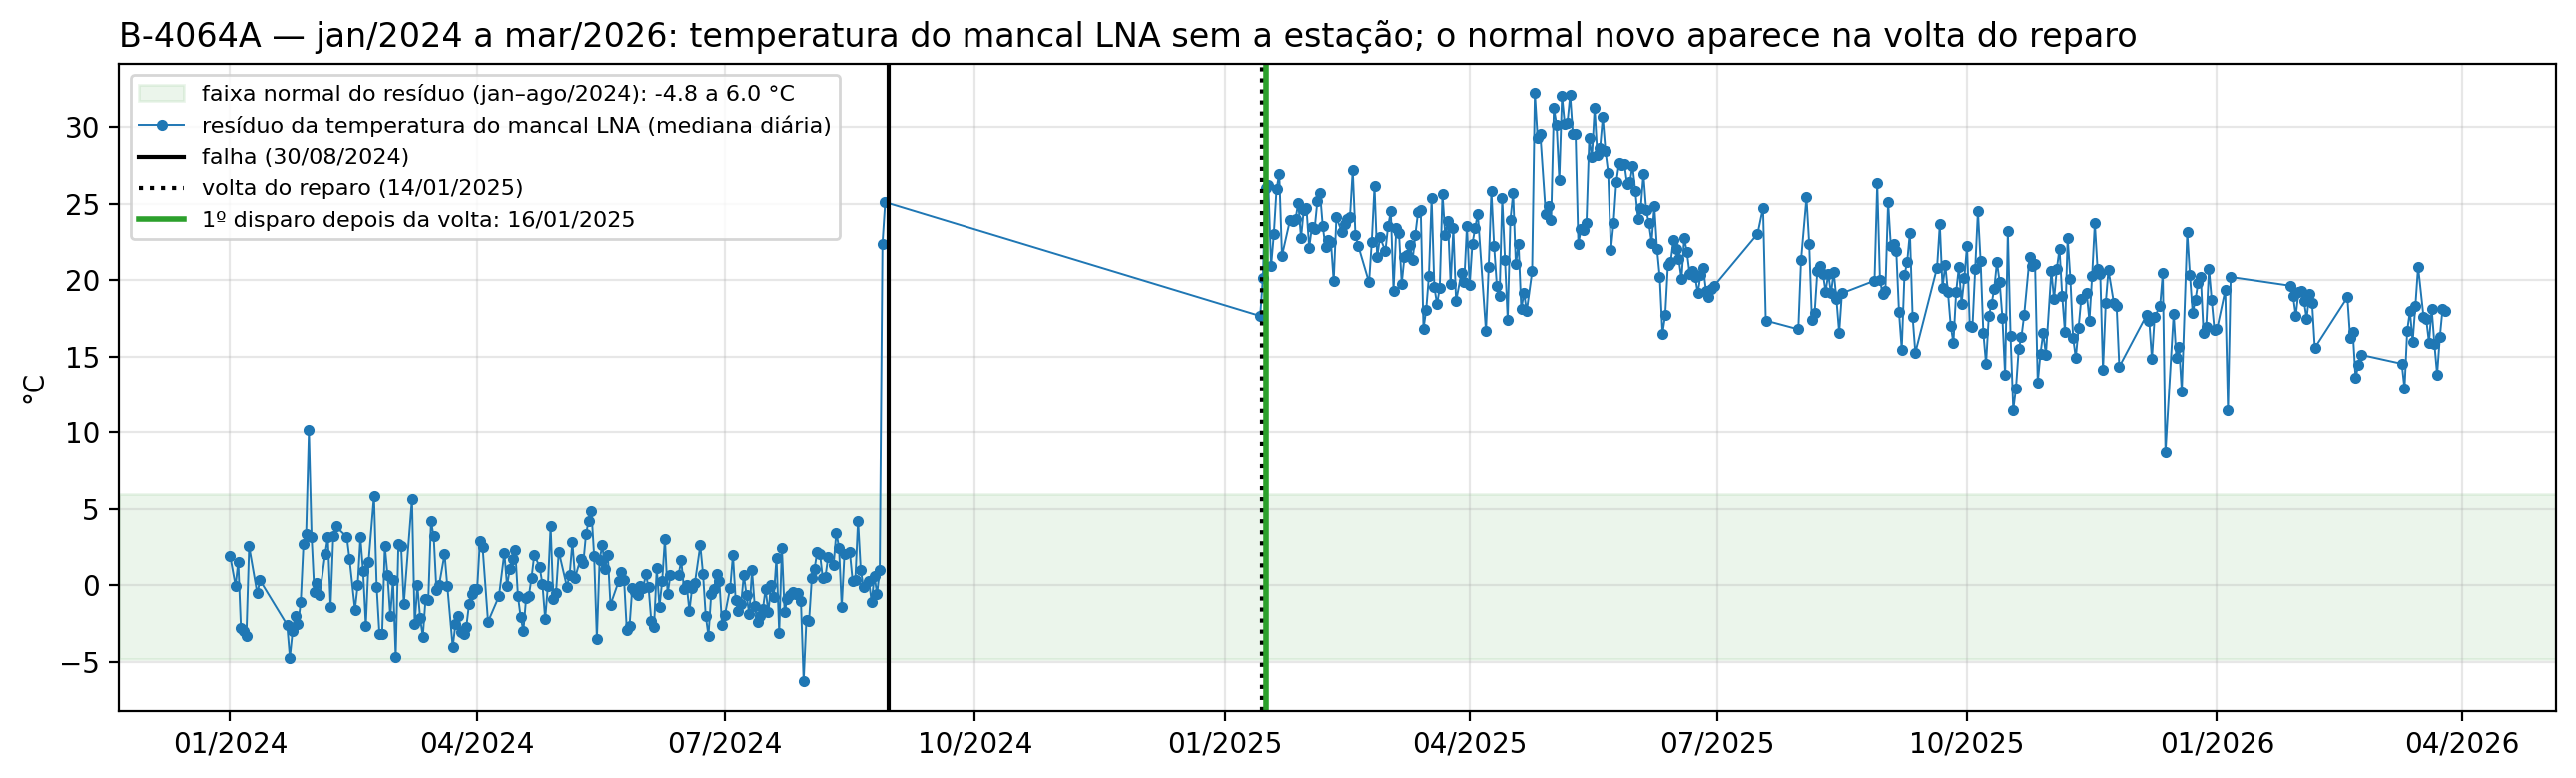

In [12]:
ks = lambda ref, w: CalibratedKSDetector(ref, window_size=w, n_reference=mon.M6_NREF, sampling="quantile")
nfalsos = lambda f: f"{len(f)} disparos falsos" + (": " + "; ".join(f"{t:%d/%m/%y} ({', '.join(s)})" for t, s in f) if f else "")
linhas = []
s25 = serie.loc["2025"]
_, f = ks(s25[:"2025-06-30"], 288).scan(s25["2025-07-01":], reset_gap="3D")
linhas.append({"equipamento": "B-8802B", "teste": "controle: referência de 6 meses (jan–jun/2025), varre jul–dez/2025",
               "KS na série bruta": nfalsos(f), "nível no resíduo": "—"})
_, f = ks(s25, 288).scan(serie.loc["2026":"2026-03-16"], reset_gap="3D")
linhas.append({"equipamento": "B-8802B", "teste": "controle: referência de 12 meses (2025), varre jan–16/03/2026",
               "KS na série bruta": nfalsos(f),
               "nível no resíduo": nfalsos([(t, ["Temperatura Bomba LA"]) for t in disp_nivel if pd.Timestamp("2026-01-01") <= t <= pd.Timestamp("2026-03-16")])})

from transpetro_modelos.config import EQUIPMENT_CONFIGS
from transpetro_modelos.data.preprocessing import run_preprocessing
raw4 = pd.read_feather(PROJECT_ROOT / "Dados-novos/B-4064A_novos.feather")
if "Timestamp" in raw4.columns: raw4 = raw4.set_index("Timestamp"); raw4.index = pd.to_datetime(raw4.index)
s4, _, _ = run_preprocessing(raw4.sort_index(), EQUIPMENT_CONFIGS["B-4064A-prod"].pre_split_steps)
FALHA4, VOLTA4 = pd.Timestamp("2024-08-30 07:58"), pd.Timestamp("2025-01-14 12:00")
X4 = ["Temperatura Motor LA", "Temperatura Motor LNA", "Corrente", "Pressão Descarga", "Pressão Sucção"]
res4 = lambda ref: ResidualLevelDetector("Temperatura Bomba LNA", X4).fit(ref)
casos4 = [("mudança real: volta do reparo em 14/01/2025", s4[:"2024-08-20"], s4[VOLTA4:], True),
          ("controle: referência de 4 meses (jan–abr/2024), varre mai–20/ago/2024", s4[:"2024-04-30"], s4["2024-05-01":"2024-08-20"], False),
          ("controle: 12 meses do normal novo (jan/2025–jan/2026), varre 2026", s4[VOLTA4:"2026-01-13"], s4["2026-01-14":], False),
          ("rampa de ~2 dias da falha de 30/08/2024", s4[:"2024-08-20"], s4["2024-08-21":FALHA4], False)]
for nome, ref, varre, mudanca in casos4:
    _, f = ks(ref, 24).scan(varre, reset_gap="3D")
    _, fr = res4(ref).scan(varre)
    if mudanca:
        txt_ks = f"{(f[0][0] - VOLTA4).total_seconds() / 86400:.1f} dias, via {', '.join(f[0][1])}" if f else "não detecta"
        txt_res = f"{(fr[0] + pd.Timedelta(days=1) - VOLTA4).total_seconds() / 86400:.1f} dias" if fr else "não detecta"
    else:
        txt_ks, txt_res = nfalsos(f), nfalsos([(t, ["Temperatura Bomba LNA"]) for t in fr])
    linhas.append({"equipamento": "B-4064A", "teste": nome, "KS na série bruta": txt_ks, "nível no resíduo": txt_res})
pd.set_option("display.max_colwidth", 140)
display(pd.DataFrame(linhas).set_index(["equipamento", "teste"]))

# a mudança do B-4064A vista pelo resíduo
det4 = res4(s4[:"2024-08-20"])
d4, f4 = det4.scan(s4)
fig, ax = plt.subplots(figsize=(13, 4))
ax.axhspan(*det4.band, color="green", alpha=0.08, label=f"faixa normal do resíduo (jan–ago/2024): {det4.band[0]:.1f} a {det4.band[1]:.1f} °C")
ax.plot(d4.index, d4, marker=".", linewidth=0.7, label="resíduo da temperatura do mancal LNA (mediana diária)")
ax.axvline(FALHA4, color="black", linewidth=1.5, label="falha (30/08/2024)")
ax.axvline(VOLTA4, color="black", linestyle=":", linewidth=1.5, label="volta do reparo (14/01/2025)")
f4d = [t for t in f4 if t >= VOLTA4]
ax.axvline(f4d[0], color="tab:green", linewidth=2, label=f"1º disparo depois da volta: {f4d[0]:%d/%m/%Y}")
ax.set_ylabel("°C"); ax.grid(alpha=0.3); ax.legend(loc="upper left", fontsize=8)
ax.set_title("B-4064A — jan/2024 a mar/2026: temperatura do mancal LNA sem a estação; o normal novo aparece na volta do reparo", loc="left")
ax.xaxis.set_major_formatter(mdates.DateFormatter("%m/%Y")); plt.tight_layout(); plt.show()

**Leitura.**
- **A estação engana o KS quando a referência não cobre o ano:** com 6 meses de referência no B-8802B e 4 meses no
  B-4064A, ele dispara na outra metade do ano (temperaturas e pressão de sucção). Com 12 meses, nenhum disparo falso.
  Por isso a política pede 12 meses de referência.
- **O detector no resíduo não se deixa enganar pela estação:** 0 disparos falsos em todos os controles, inclusive com
  a referência de só 4 meses do B-4064A, onde o KS erra.
- **Ele também acha a mudança real do B-4064A**, em ~2 dias (o KS, em 3), e não dispara na rampa de 2 dias da falha:
  falhas de horas a poucos dias ficam com o modelo de anomalia, que alertou 2,1 dias antes da falha de 2022 do B-8802B.
- **O B-4064A é um equipamento que o detector no resíduo não tinha visto**: ele foi ajustado olhando o B-8802B, e o
  resultado se repetiu. A temperatura do mancal LA do B-4064A ficou de fora: tem falha de sensor em mar–abr/2024
  (~16 °C), e a regressão não se ajusta.

## 8. Sazonalidade: o que a literatura propõe

As seções 6 e 7 mostraram o problema na prática: uma referência que não cobre o ano confunde estação com mudança. As
técnicas mais usadas, do modelo de anomalia ao detector:

| técnica | ideia | para o modelo | para o detector | situação aqui |
|---|---|---|---|---|
| **referência de 12 meses** | o "normal" já contém todas as estações | treinar com 1 ano | calibrar com 1 ano | **já é a política**; 0 falsos em 2026 |
| **modelo de comportamento normal (NBM) / resíduo** | prever um sensor a partir das condições (carga, ambiente, outros sensores) e monitorar só o resíduo | o resíduo não tem estação | rodar o KS no resíduo, não no sensor bruto | **feito para as temperaturas de mancal** (`drift/residuo.py`): validado no B-8802B e no B-4064A |
| **condicionar no contexto** | dar ao modelo a época do ano (seno/cosseno do dia do ano) ou a temperatura ambiente | autoencoder condicional (CVAE) | comparar só períodos parecidos (mesmo regime ou estação) | não temos tag de temperatura ambiente; dia do ano é um substituto |
| **decomposição sazonal (STL, remoção de tendência)** | subtrair a componente lenta | série sem estação | idem | arriscado: também apaga degradação lenta. O experimento `detrend7d` (task `d49fc928`) trocou os alarmes de lugar e foi descartado |
| **conceitos recorrentes** | guardar um modelo/referência por estação e trocar quando ela volta | um modelo por estação | uma referência por estação | precisa de vários anos de dado de cada equipamento |

Referências: Gama et al. (2014), *A survey on concept drift adaptation*, ACM Computing Surveys; Lu et al. (2019),
*Learning under concept drift: a review*, IEEE TKDE; Tautz-Weinert & Watson (2017), *Using SCADA data for wind
turbine condition monitoring – a review*, IET Renewable Power Generation (modelos de comportamento normal e
resíduos); Cleveland et al. (1990), *STL: a seasonal-trend decomposition procedure based on loess*.

**Para o B-8802B**, a combinação que ficou é: referência fixa de 12 meses (o período do treino), KS para vibrações e
pressões, e o resíduo para as temperaturas de mancal. A mudança de 2026 **não é estação**: o resíduo a deixa mais
visível, não menos. Ela precisa de uma resposta da operação, não de uma feature que a esconda.

## 9. Resumo

| caso | referência | o detector | certo? |
|---|---|---|---|
| B-8802B, dado congelado (353 h em 19 meses) | — | removido do treino e do detector; vira aviso M7 no monitor | sim: é falha de aquisição |
| B-8802B, reparo de 2022 → 2025 | mai–jun/2022 | KS disparou em 06/01/2025, **4 dias** | sim, mudança de conceito real |
| B-8802B, ciclo depois do disparo | cresce de jan/2025 até jan/2026 | quarentena → maturação → madura; nenhum disparo em 2026 | sim |
| B-8802B, mancal LA em 2026 | 2025 | KS bruto: nada robusto (27/06 no pacote, limítrofe); **resíduo: 01/04/2026, 4 dias** | o resíduo sim |
| B-8802B, janela deslizante | últimos 12 meses | resíduo: 16/04 e para em maio; KS bruto: nada | não: absorve a mudança |
| B-8802B, controles | 6 e 12 meses | KS: falsos com 6 meses, 0 com 12; resíduo: 0 | 12 meses / resíduo |
| B-4064A, volta do reparo | jan–ago/2024 | KS: 3 dias; **resíduo: ~2 dias** | sim |
| B-4064A, controles | 4 e 12 meses | KS: 2 falsos com 4 meses (estação); resíduo: 0 | o resíduo sim |

**O que mudou no código** (`src/transpetro_modelos/drift/`)
- `detectors.py`: o KS resume a referência por **quantis** (`sampling="quantile"`), sem sorteio, e a varredura zera a
  persistência em paradas de mais de 3 dias (`reset_gap`).
- `monitor.py`: aviso **M7 de dado congelado**; o dado congelado fica fora do KS; a calibração usa quantis.
- `residuo.py`: o **detector no resíduo** (`ResidualLevelDetector`), validado em dois equipamentos.
- `data/preprocessing.py` e o pacote de deploy: passo `remove_frozen_segments`.

**Próximos passos**
1. **Perguntar à operação** o que foi feito nas paradas de 17/03 e 27/03/2026 (seção 6), e verificar os períodos de
   dado congelado com a instrumentação.
2. **Levar o detector no resíduo para o monitor semanal**, para as temperaturas de mancal, com a referência e a
   regressão guardadas no bundle (como o `drift_ref.json`).
3. **Recalibrar o `drift_ref.json` do B-8802B-2025** (quantis, sem dado congelado) na próxima entrega do pacote, e
   usar `remove_frozen_segments` nos próximos treinos.
4. **Recalibrar os detectores junto com cada retreino**, inclusive nos modelos provisórios do retreino acumulativo.